## Loading and Plotting the Raw Spectra

The following function reads any Ba11/ISO `.dat` spectrum file and converts
the recorded *time axis* into a correct *wavelength axis*, using the metadata
(start wavelength, gear factor, scan direction).

It also:
- converts commas to dots (LabVIEW formatting),
- flips the wavelength axis when needed so that λ always increases left → right,
- flips the intensity sign so peaks always point upward,
- automatically chooses the correct wavelength limits for 50 mV and 5 mV scans,
- applies uniform xticks (20 nm spacing for 50 mV, 5 nm spacing for 5 mV).

This function is the foundation for all later analysis steps.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_spectrum(filename):
    """
    Load and plot any Ba11 (ISO) spectrum file with correct wavelength axis.

    Parameters
    ----------
    filename : str
        Path to the .dat file containing the spectrum.
    """

    # --- Load file and convert commas to dots ---
    with open(filename, "r", encoding="utf-8") as f:
        header1 = f.readline().strip().replace(",", ".")  # start wavelength [nm]
        header2 = f.readline().strip().replace(",", ".")  # gear factor [nm/s]
        header3 = f.readline().strip().replace(",", ".")  # scan direction

        data = np.loadtxt(
            (line.replace(",", ".") for line in f),
            ndmin=2
        )

    # --- Parse metadata ---
    start_wavelength = float(header1)
    gear = float(header2)        # nm per second
    direction = float(header3)   # +1 or -1

    # --- Extract data ---
    t = data[:, 0]               # time [s]
    intensity_raw = data[:, 1]   # voltage [V]
    intensity = -intensity_raw   # flip sign → absorption peaks upward

    # --- Correct wavelength formula ---
    wavelength = start_wavelength + direction * gear * t

    # Flip if necessary
    if wavelength[0] > wavelength[-1]:
        wavelength = wavelength[::-1]
        intensity = intensity[::-1]

    # --- Determine x-axis behavior based on filename ---
    fname = filename.lower()

    if "5mv" in fname:
        x_min, x_max = 670, 720
        xtick_step = 5
    elif "50mv" in fname:
        x_min, x_max = 350, 720
        xtick_step = 20
    else:
        x_min = wavelength.min()
        x_max = wavelength.max()
        xtick_step = 20

    # --- Plot ---
    plt.figure(figsize=(13, 6), dpi=250)
    plt.plot(wavelength, intensity, color="black", linewidth=0.8)

    plt.title(f"Spectrum: {filename}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (V)")
    plt.grid(alpha=0.4, linestyle="--")

    plt.xlim(x_min, x_max)

    xticks = np.arange(
        np.floor(x_min / xtick_step) * xtick_step,
        np.ceil(x_max / xtick_step) * xtick_step + xtick_step,
        xtick_step
    )
    plt.xticks(xticks)

    plt.show()
    plt.close()



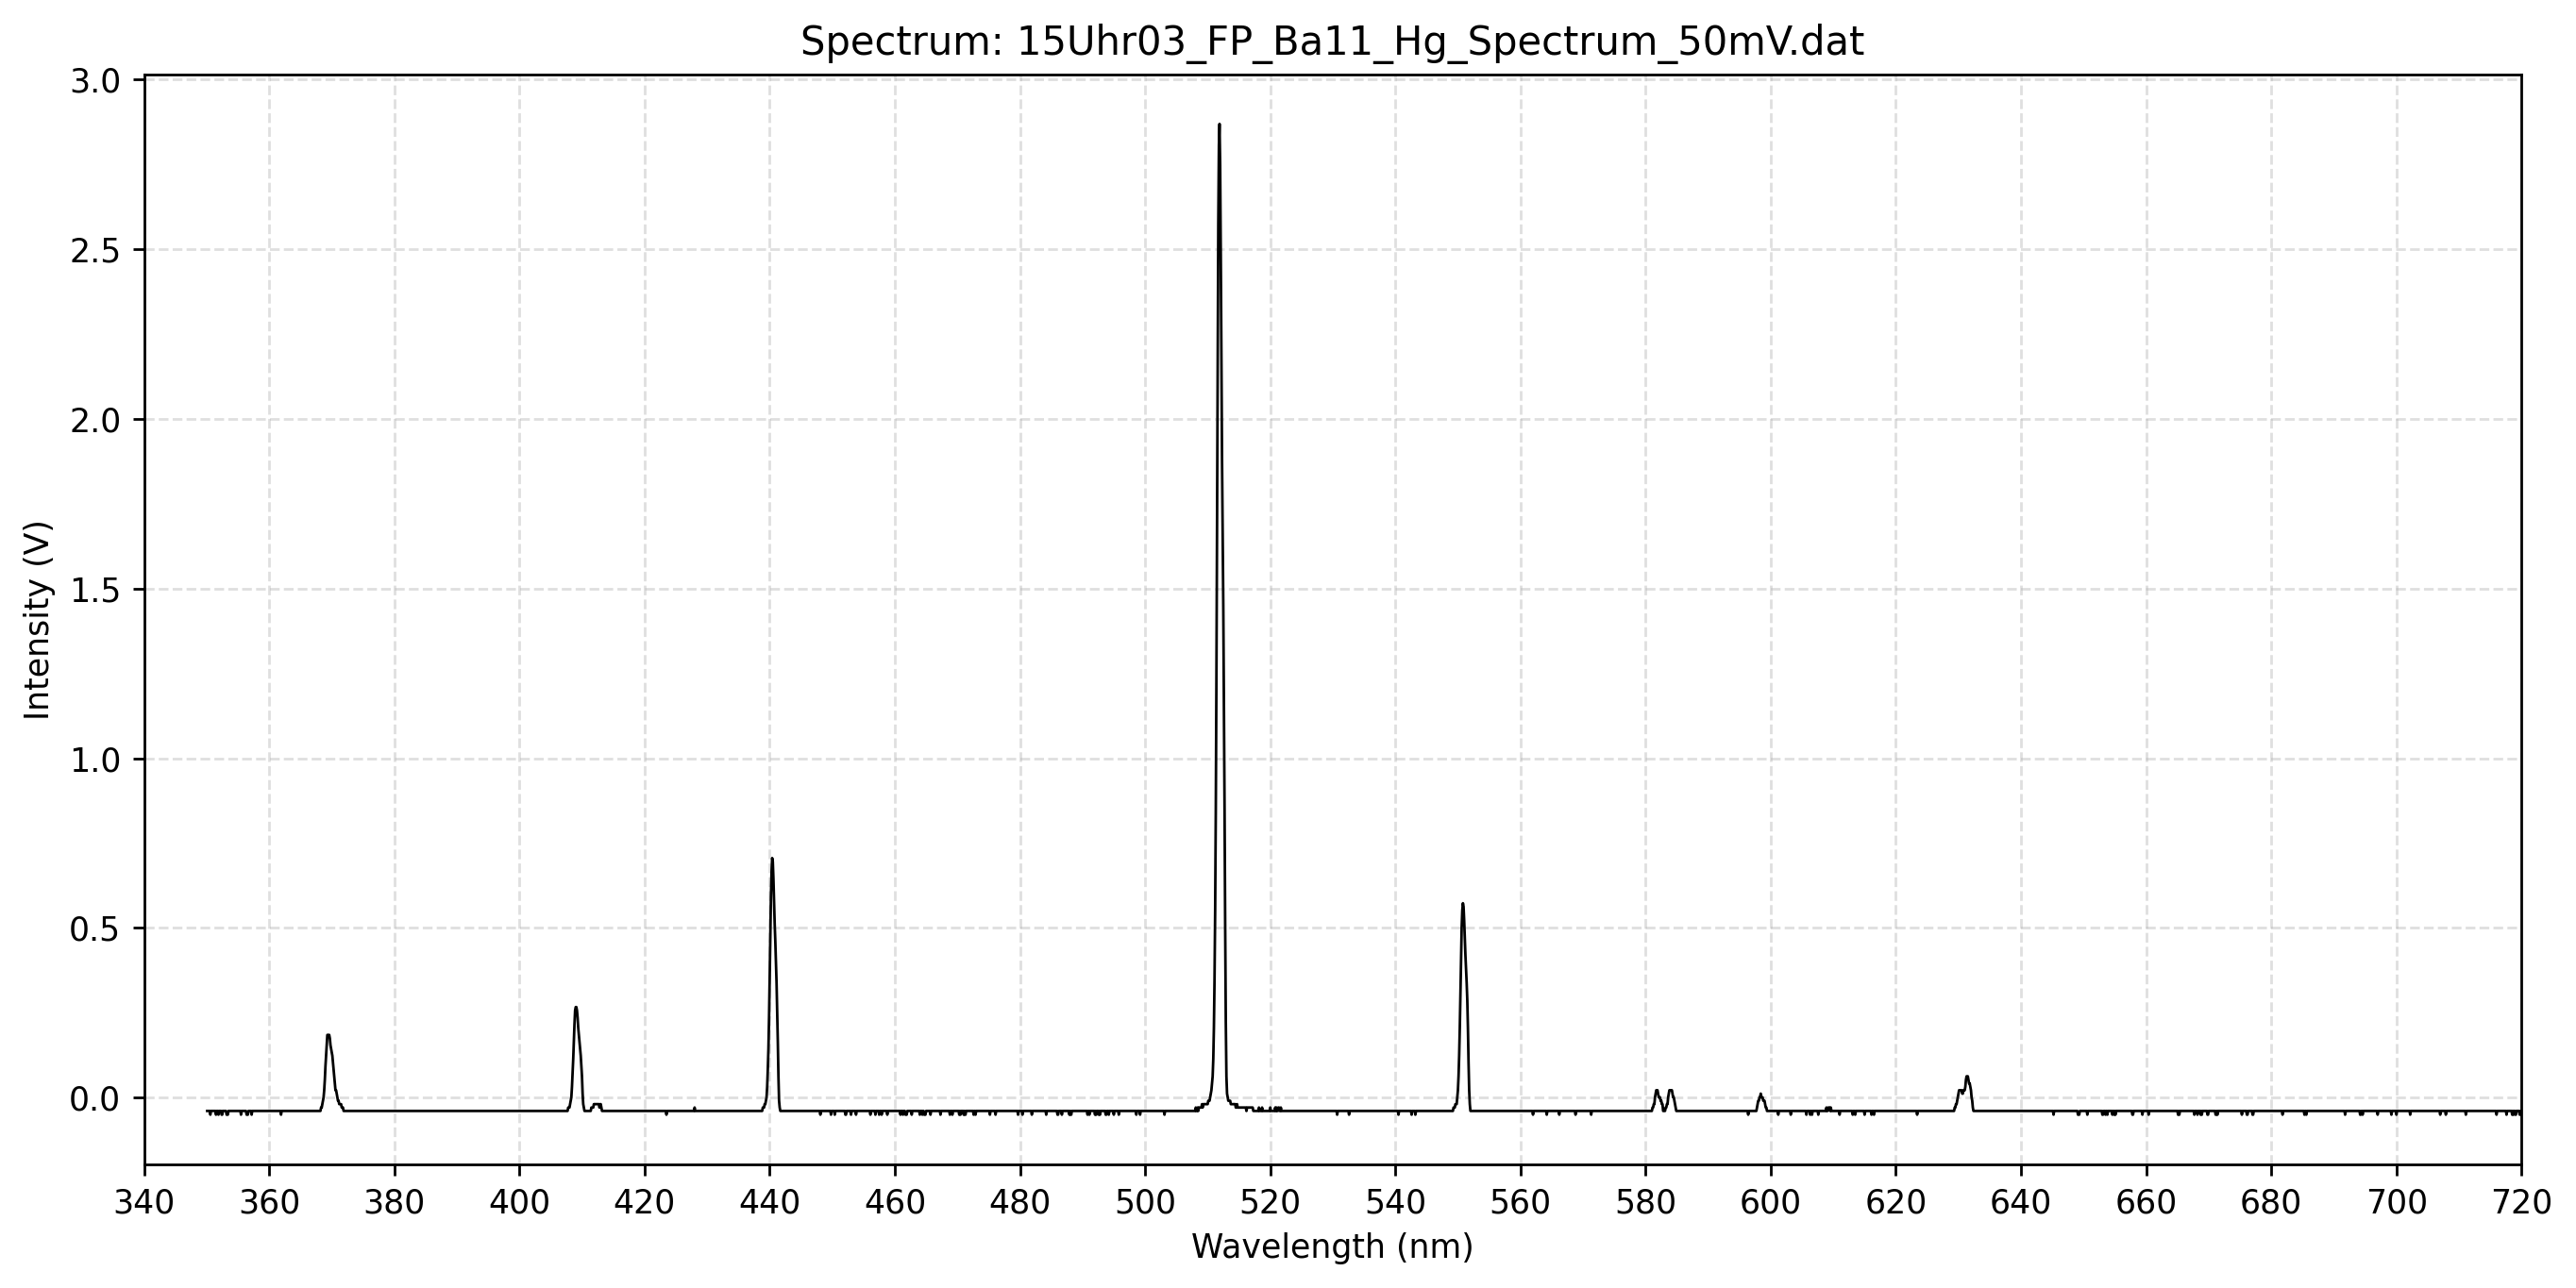

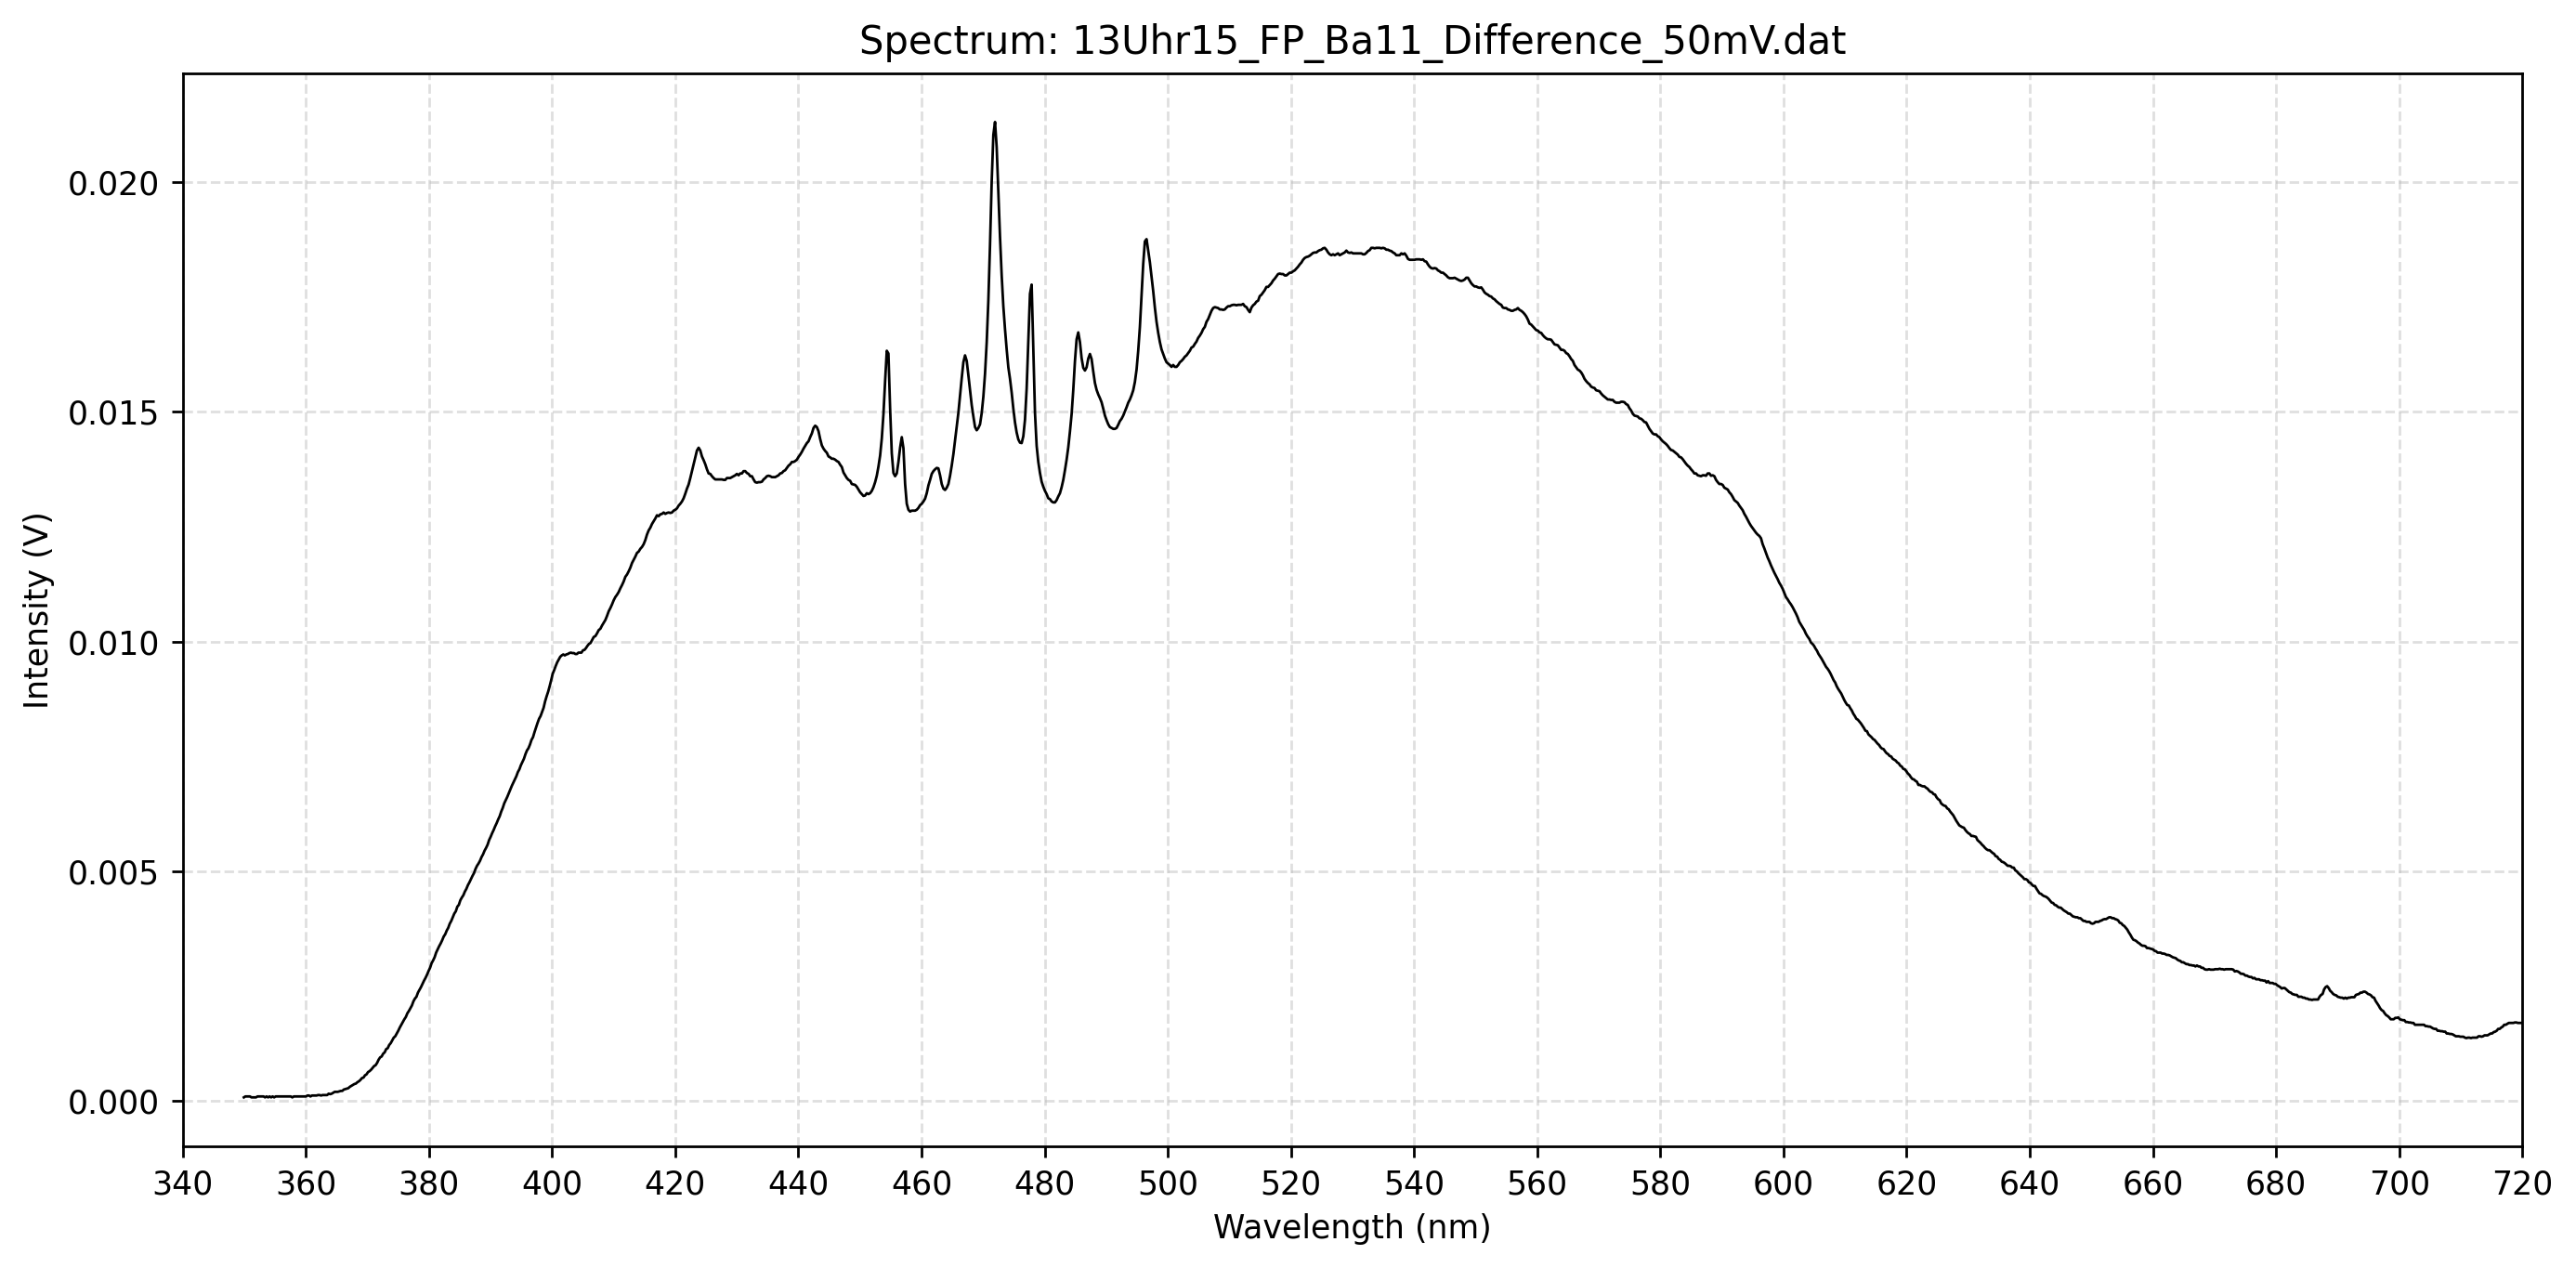

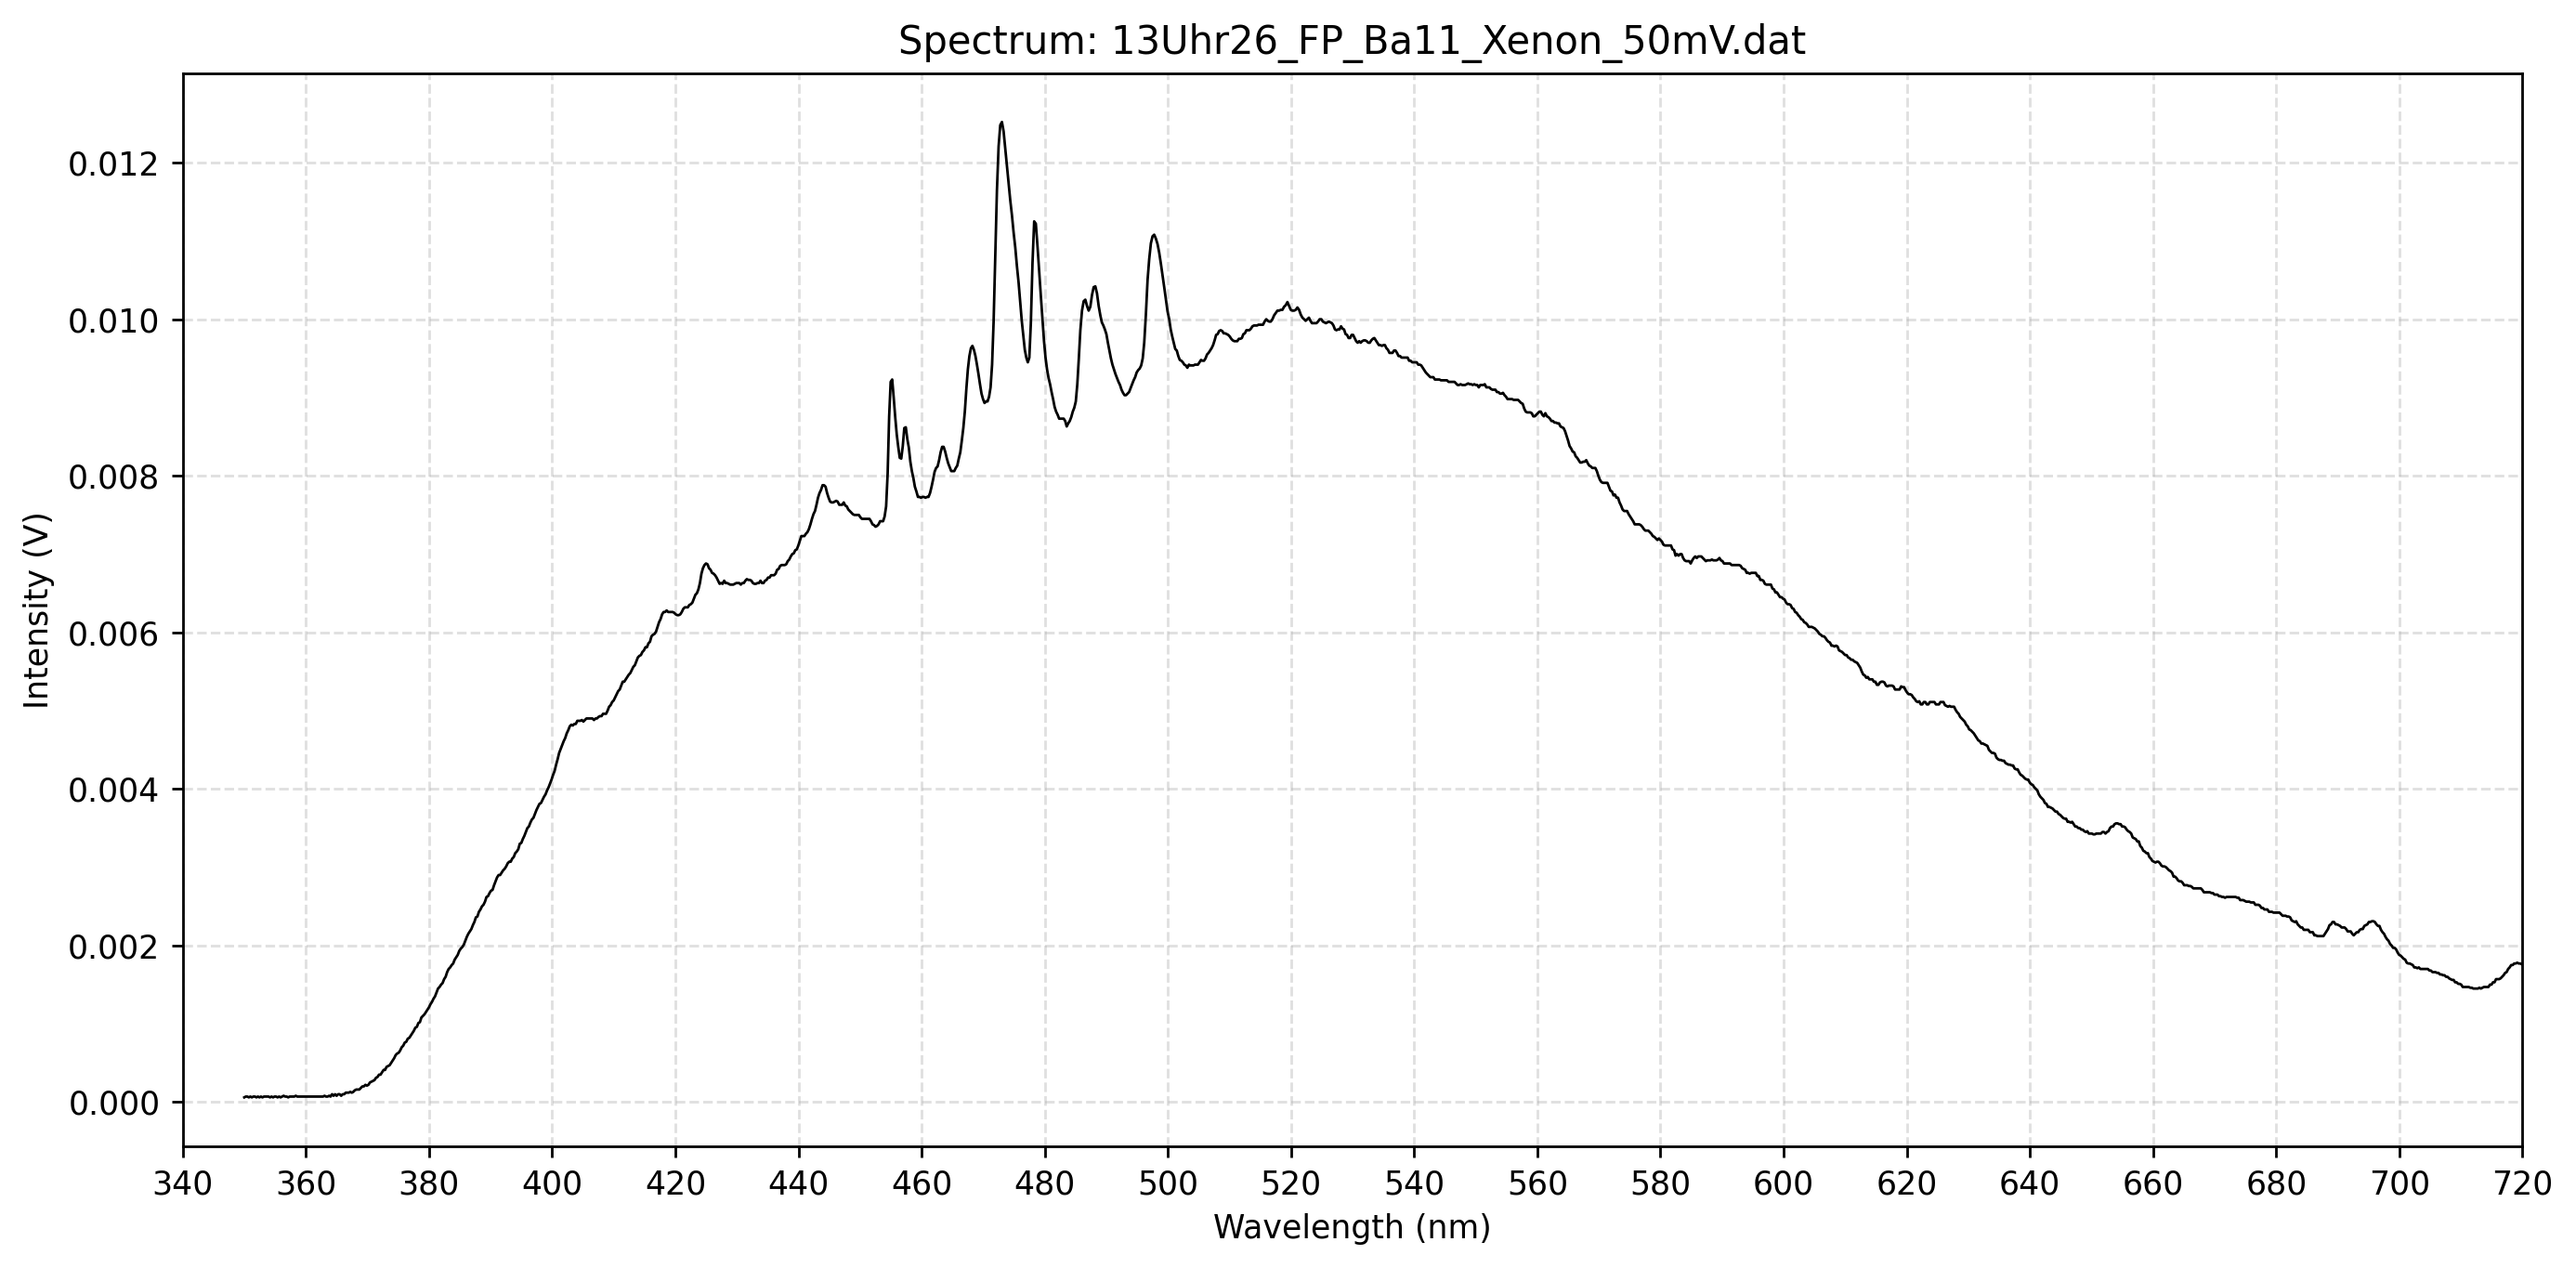

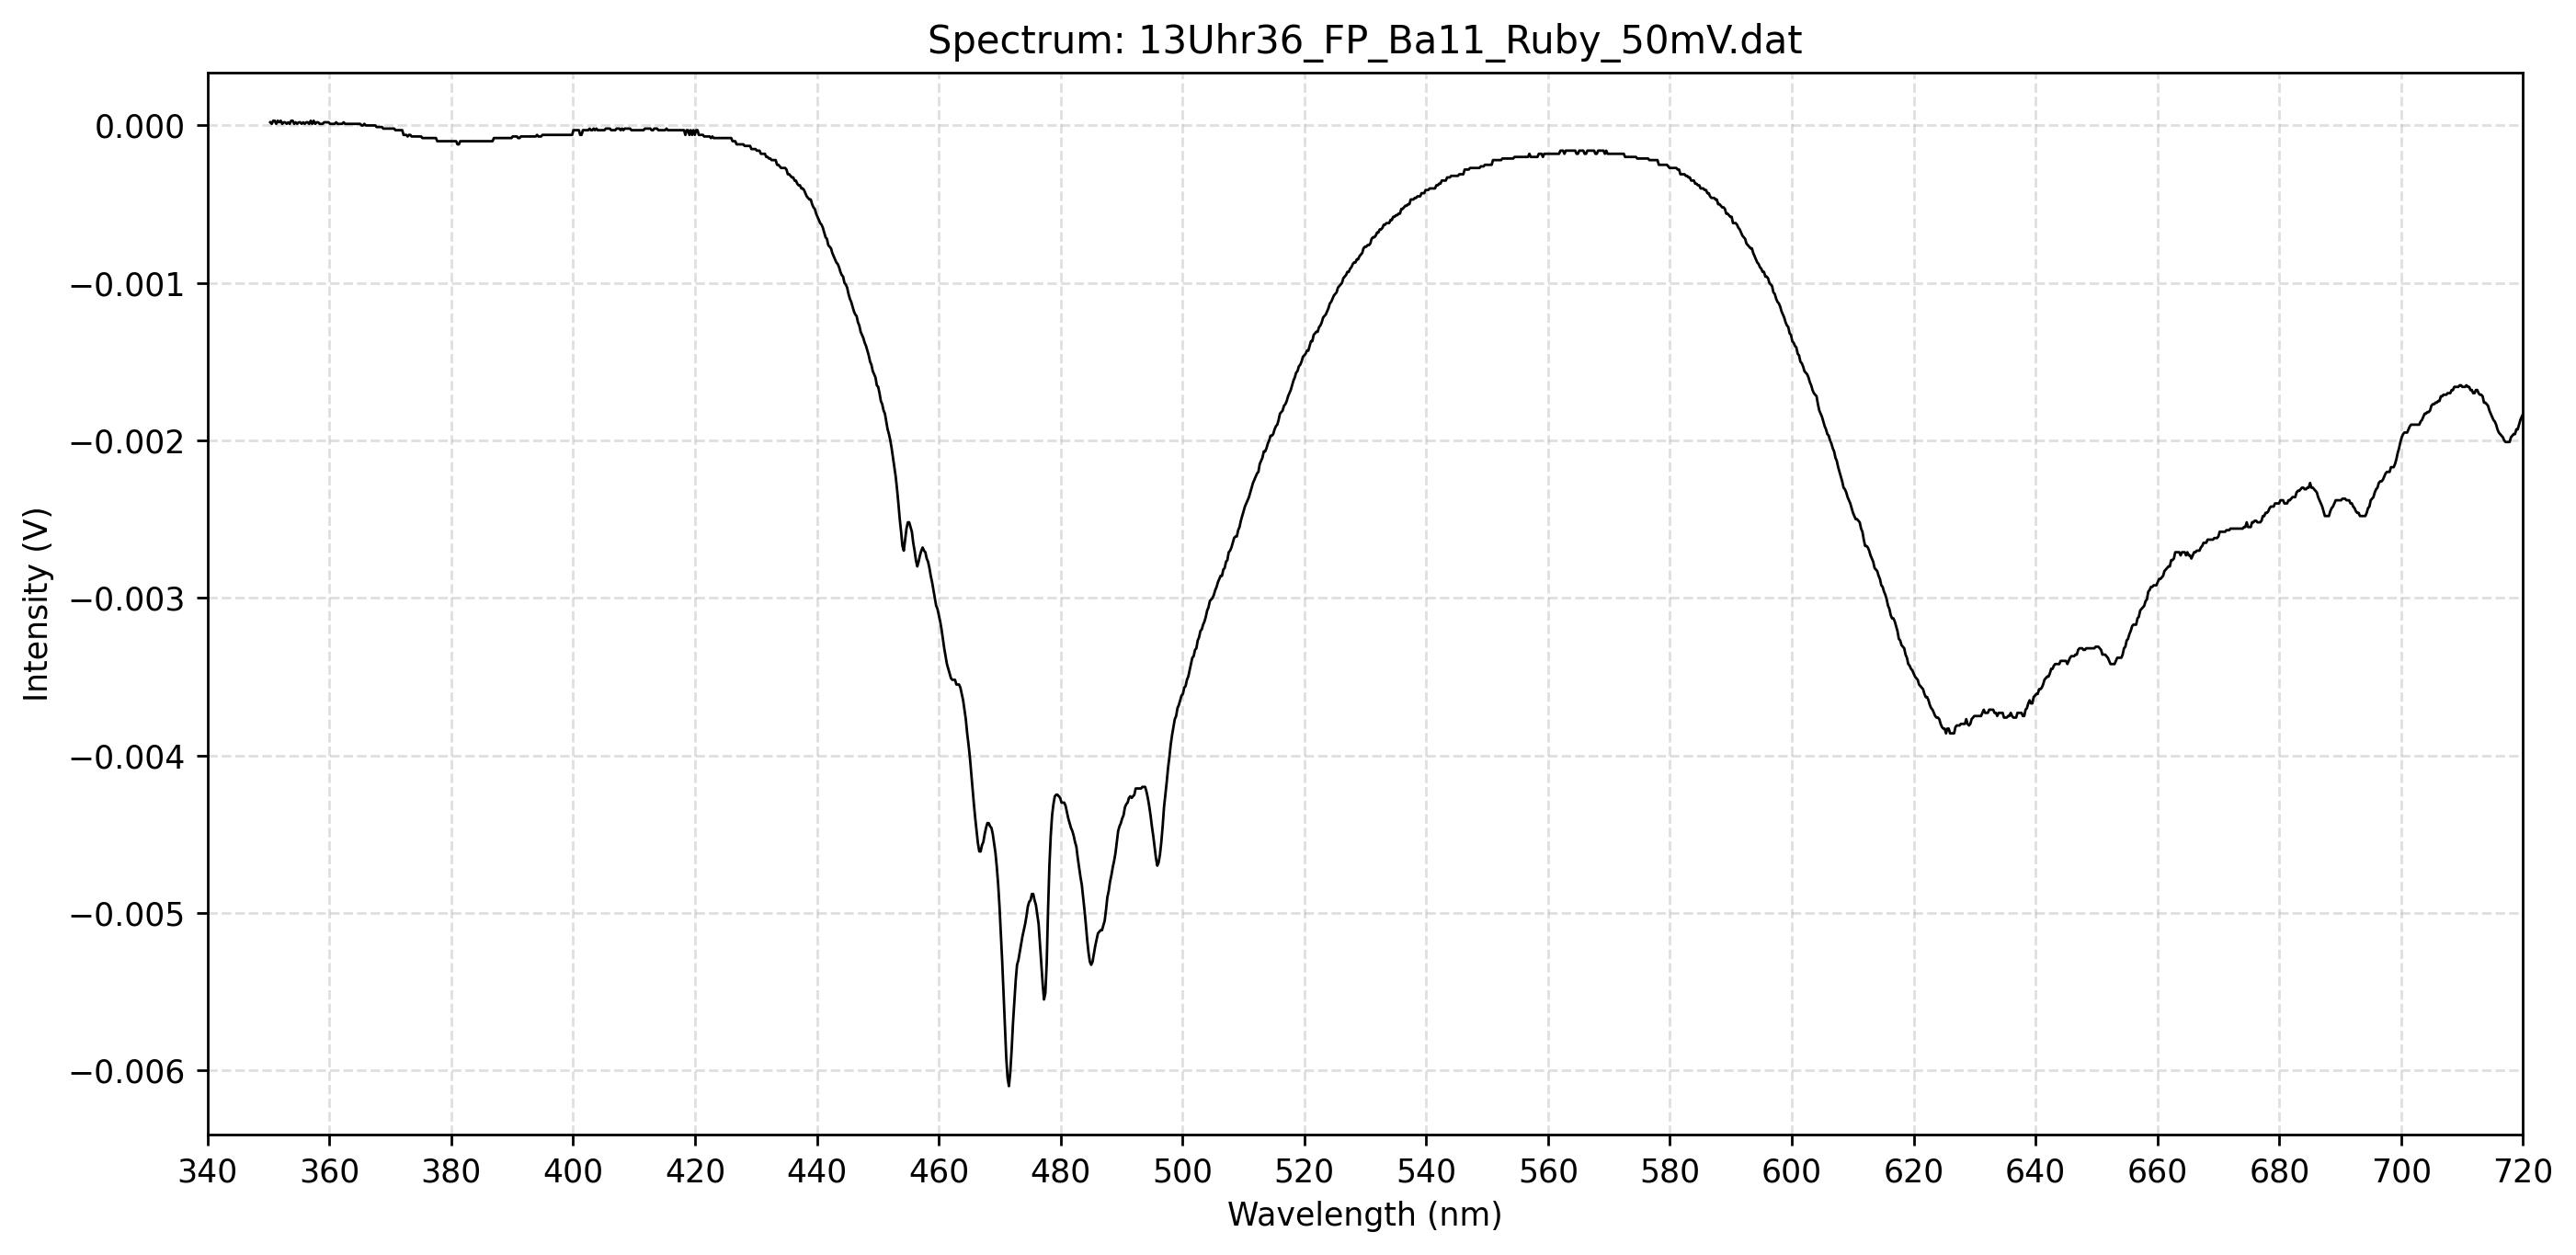

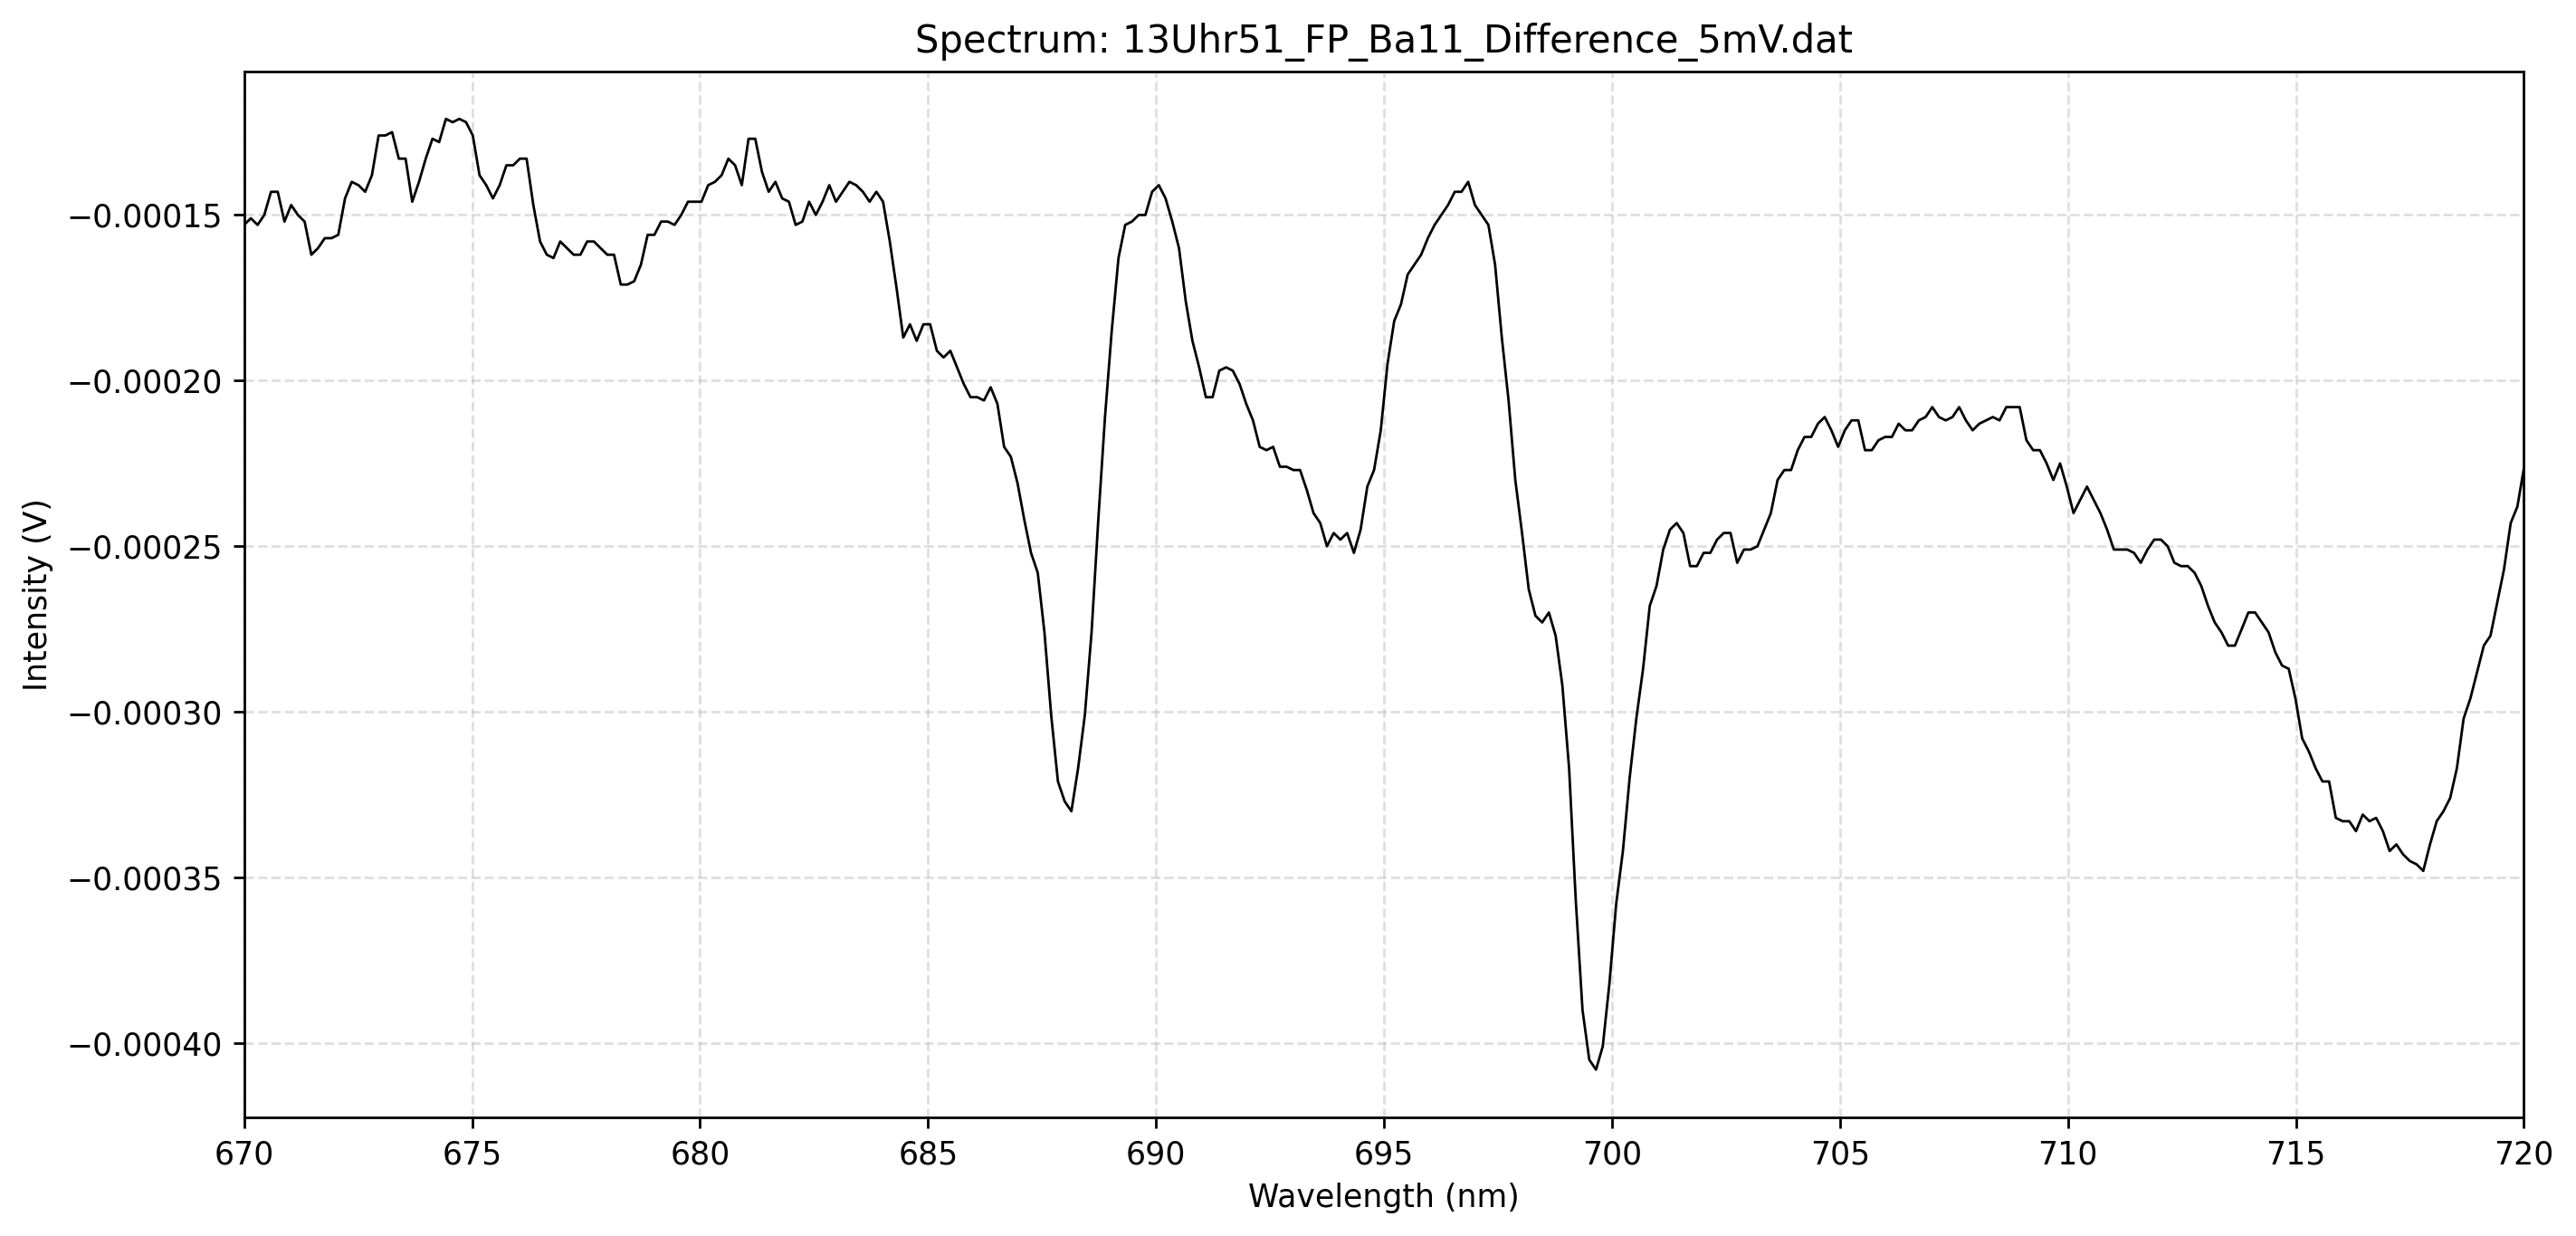

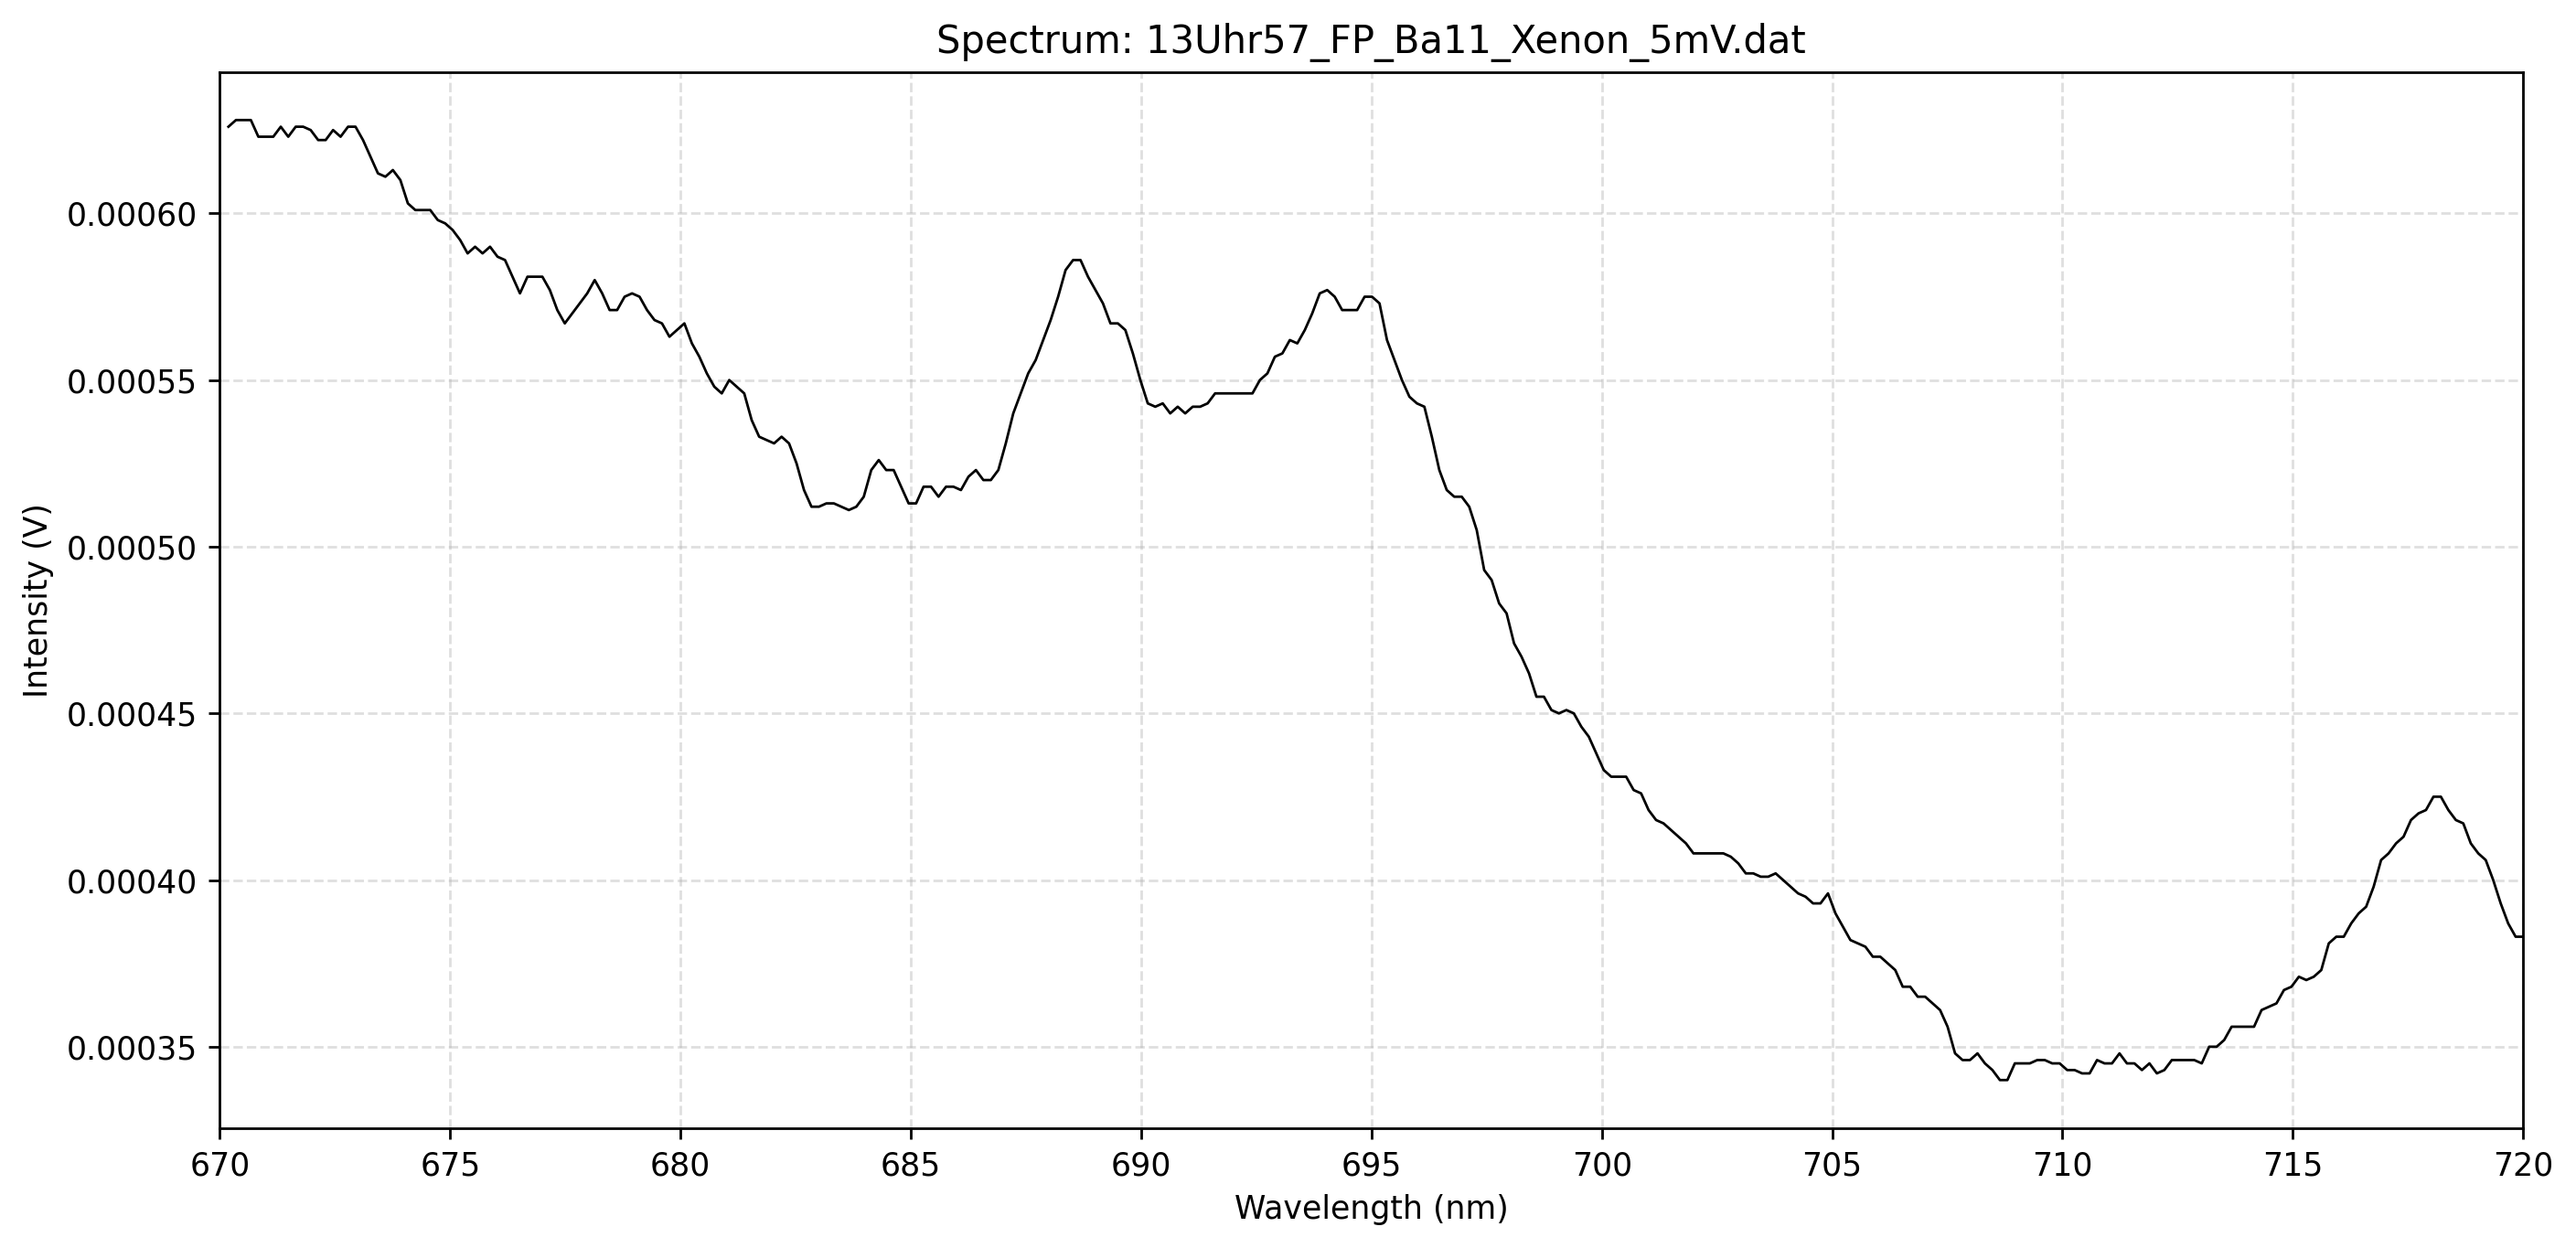

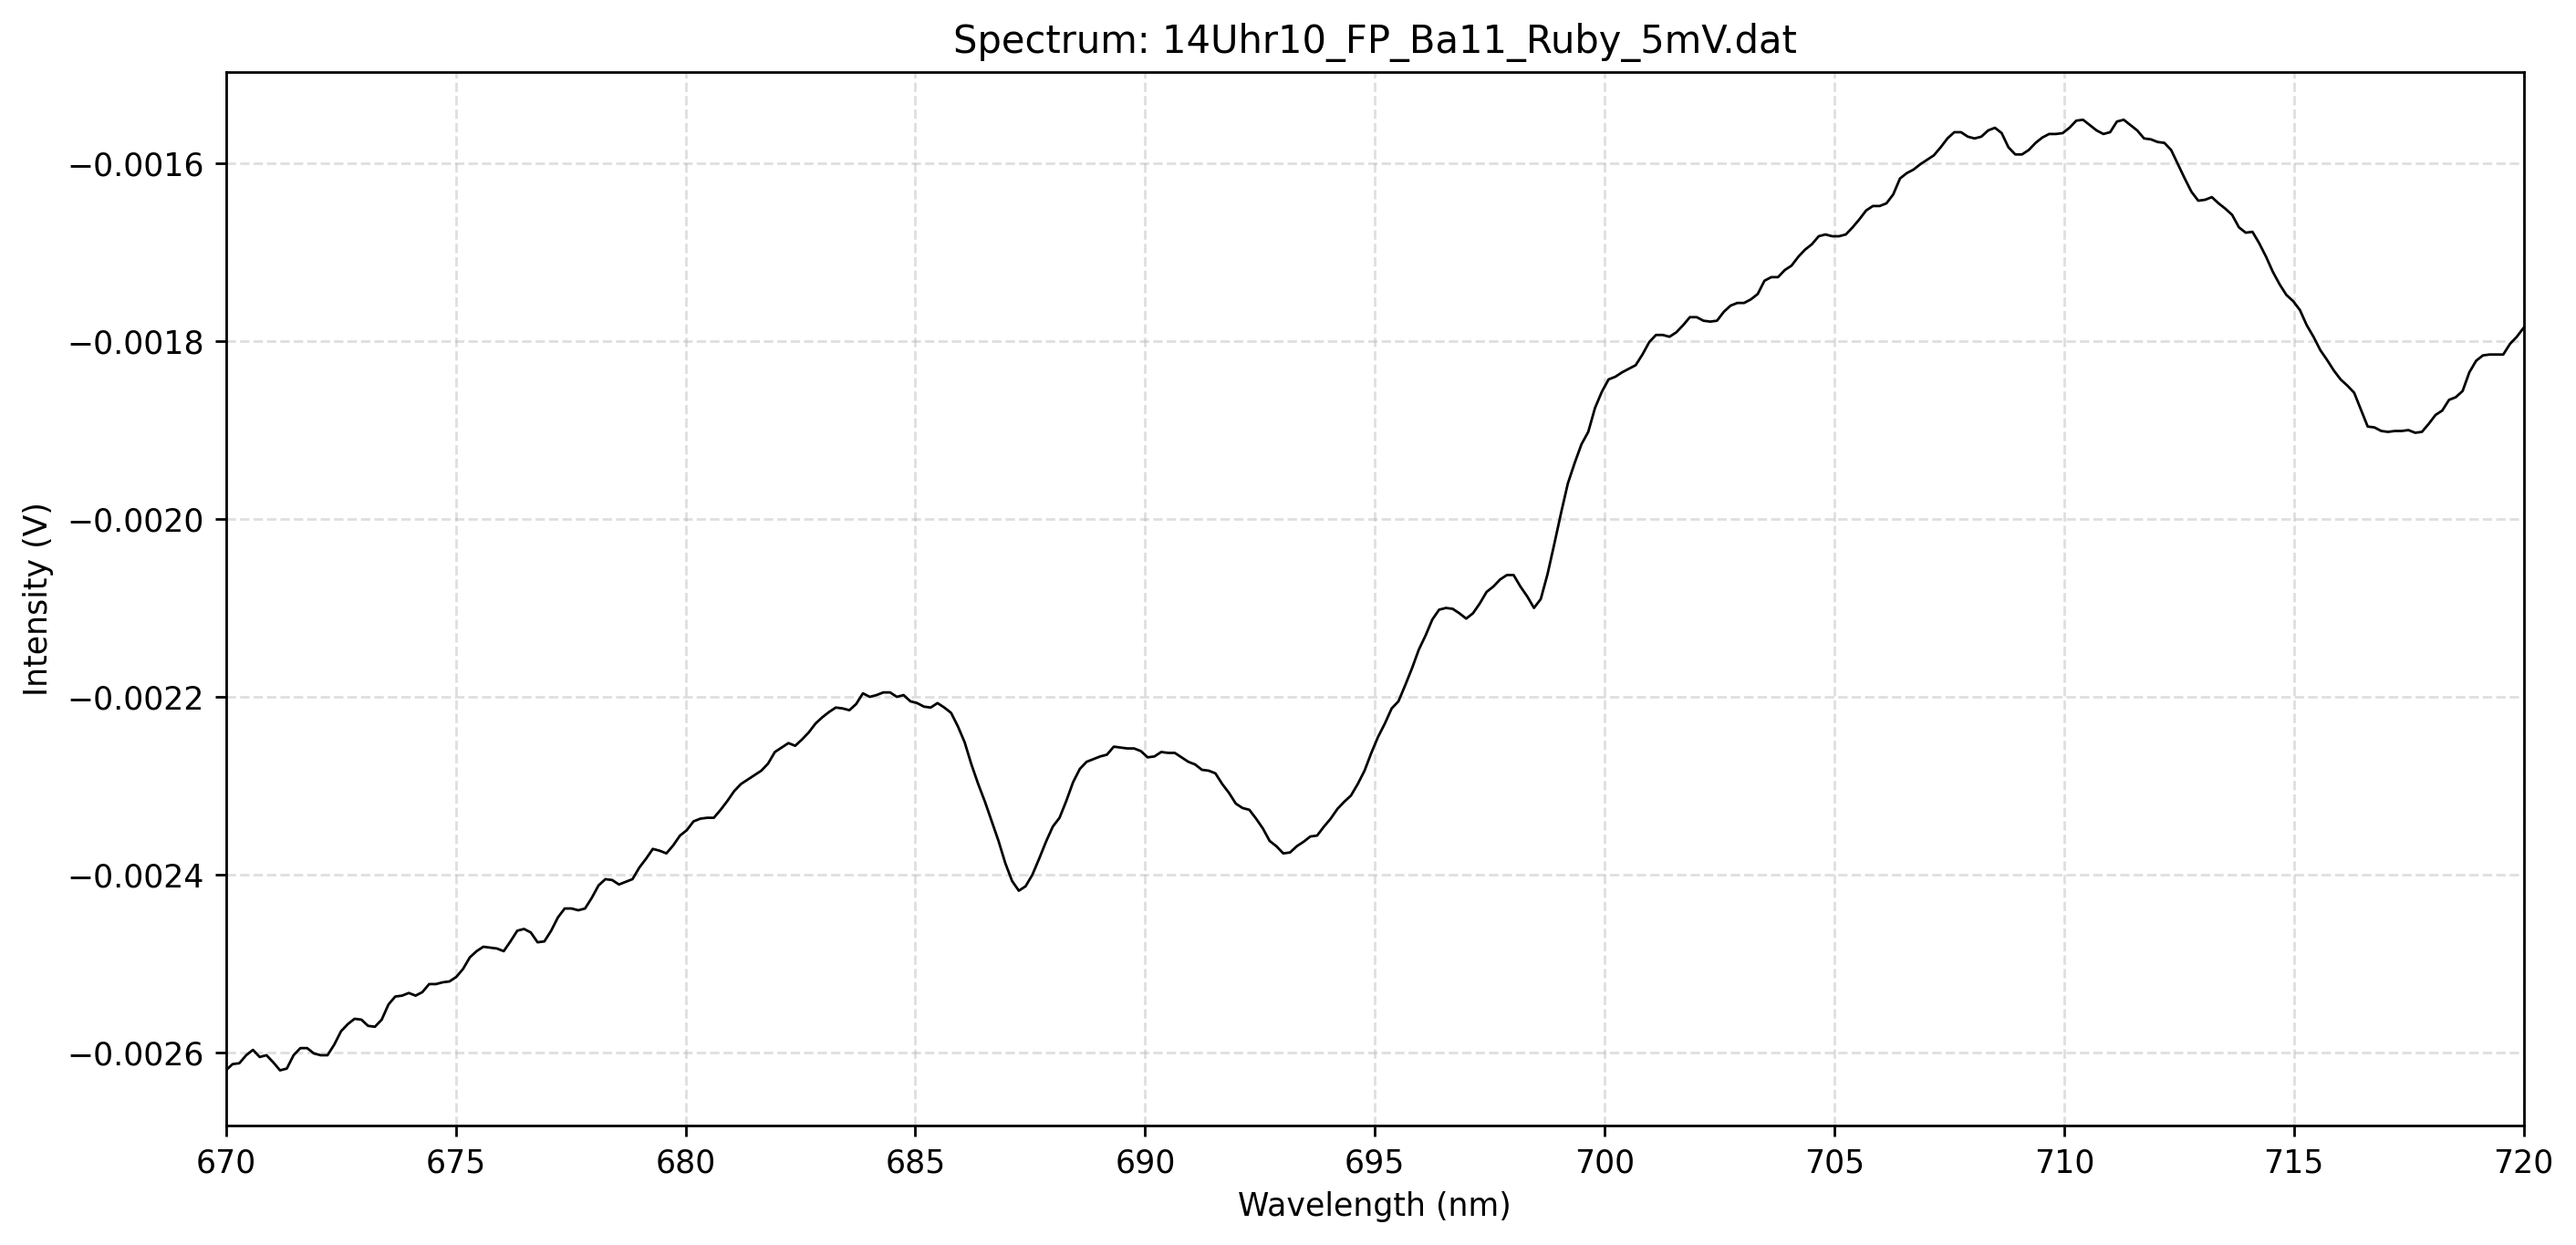

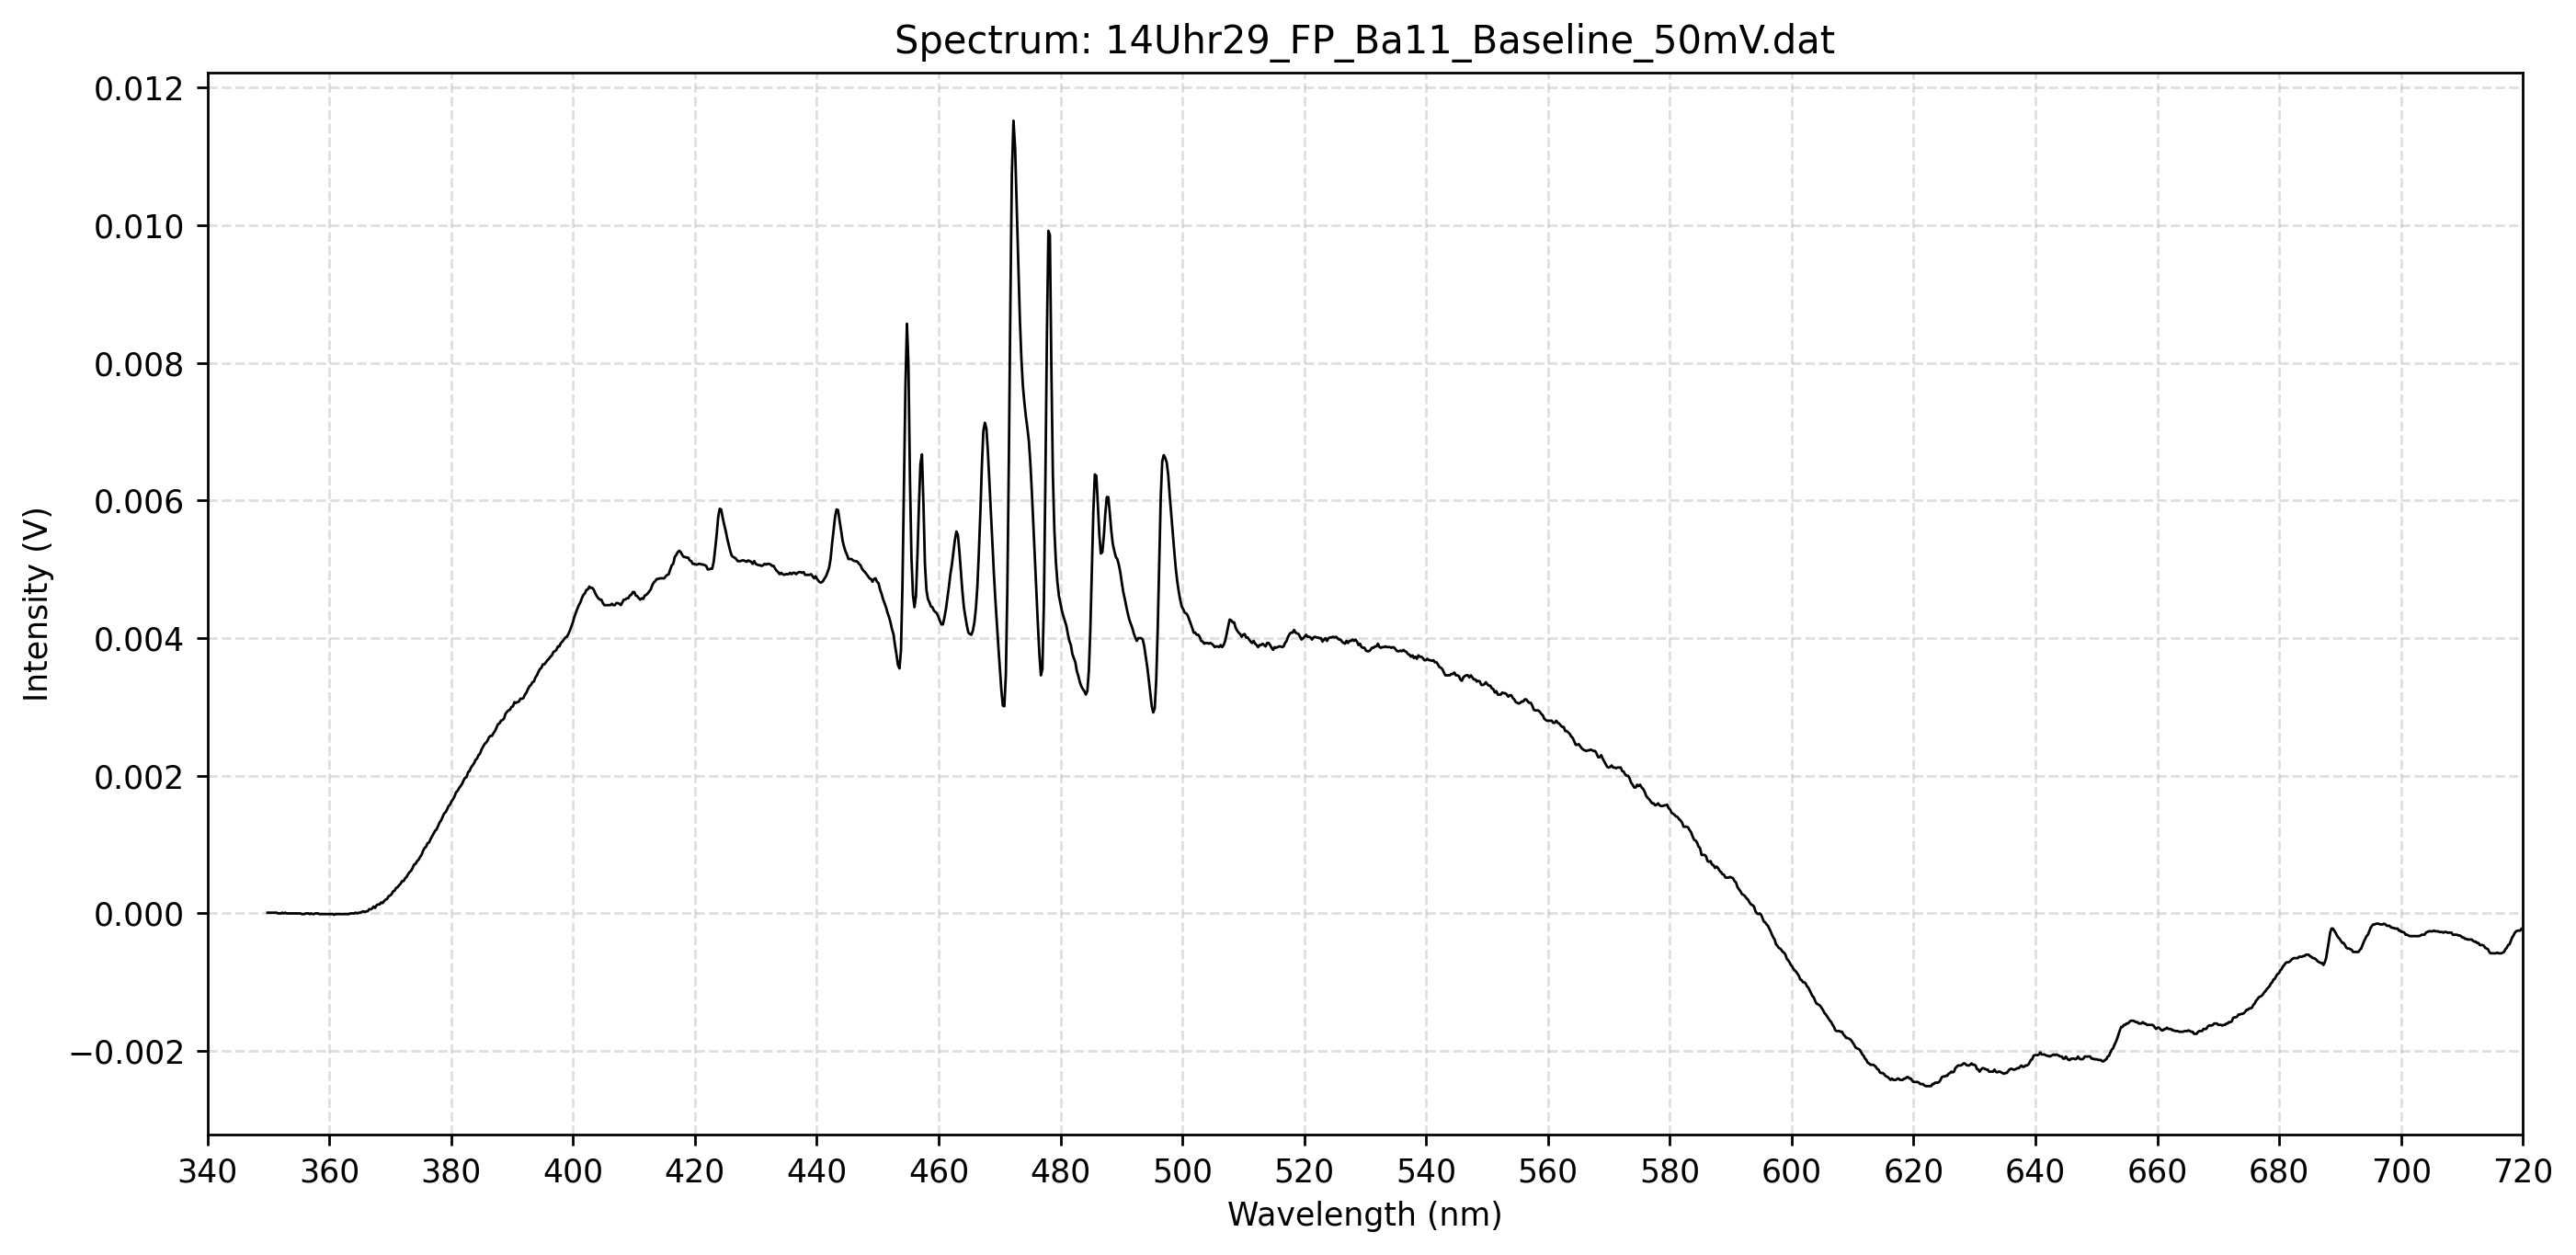

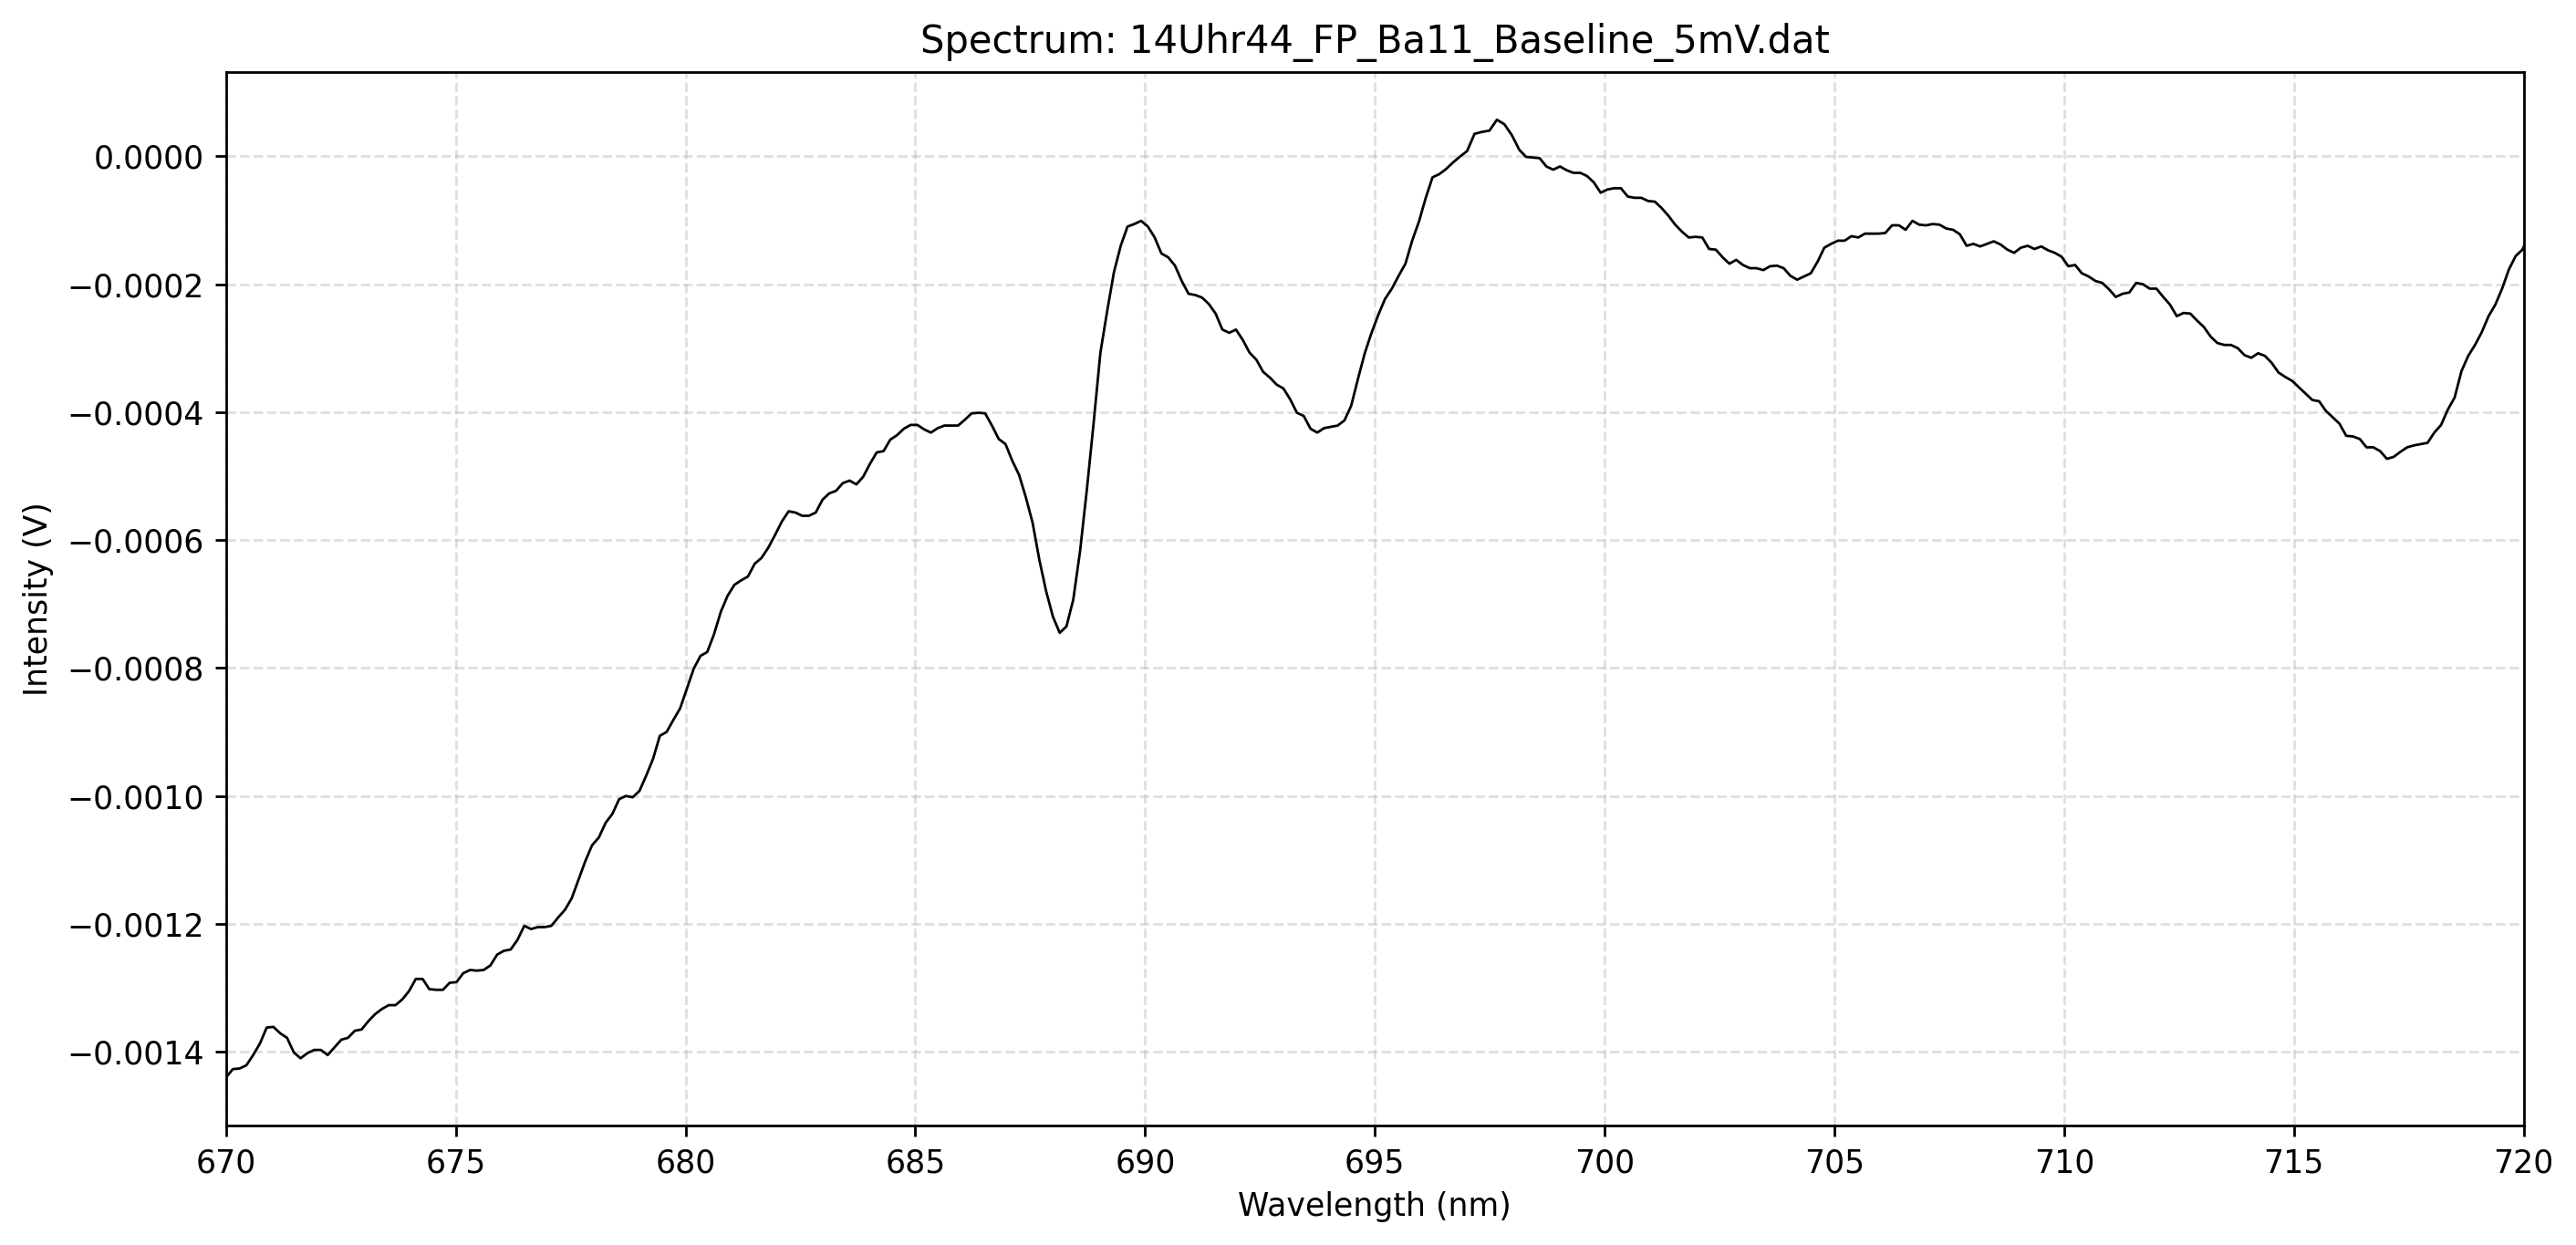

In [2]:
plot_spectrum("15Uhr03_FP_Ba11_Hg_Spectrum_50mV.dat")
plot_spectrum("13Uhr15_FP_Ba11_Difference_50mV.dat")
plot_spectrum("13Uhr26_FP_Ba11_Xenon_50mV.dat")
plot_spectrum("13Uhr36_FP_Ba11_Ruby_50mV.dat")
plot_spectrum("13Uhr51_FP_Ba11_Difference_5mV.dat")
plot_spectrum("13Uhr57_FP_Ba11_Xenon_5mV.dat")
plot_spectrum("14Uhr10_FP_Ba11_Ruby_5mV.dat")
plot_spectrum("14Uhr29_FP_Ba11_Baseline_50mV.dat")
plot_spectrum("14Uhr44_FP_Ba11_Baseline_5mV.dat")

## Combining multilple spectra


In [4]:


def extract_data(filename):
    """
    Load and plot any Ba11 (ISO) spectrum file with correct wavelength axis.

    Parameters
    ----------
    filename : str
        Path to the .dat file containing the spectrum.
    """

    # --- Load file and convert commas to dots ---
    with open(filename, "r", encoding="utf-8") as f:
        header1 = f.readline().strip().replace(",", ".")  # start wavelength [nm]
        header2 = f.readline().strip().replace(",", ".")  # gear factor [nm/s]
        header3 = f.readline().strip().replace(",", ".")  # scan direction

        data = np.loadtxt(
            (line.replace(",", ".") for line in f),
            ndmin=2
        )

    # --- Parse metadata ---
    start_wavelength = float(header1)
    gear = float(header2)        # nm per second
    direction = float(header3)   # +1 or -1

    # --- Extract data ---
    t = data[:, 0]               # time [s]
    intensity_raw = data[:, 1]   # voltage [V]
    intensity = -intensity_raw   # flip sign → absorption peaks upward

    # --- Correct wavelength formula ---
    wavelength = start_wavelength + direction * gear * t

    # Flip if necessary
    if wavelength[0] > wavelength[-1]:
        wavelength = wavelength[::-1]
        intensity = intensity[::-1]

    # --- Determine x-axis behavior based on filename ---
    fname = filename.lower()

    if "5mv" in fname:
        x_min, x_max = 670, 720
        xtick_step = 5
    elif "50mv" in fname:
        x_min, x_max = 350, 720
        xtick_step = 20
    else:
        x_min = wavelength.min()
        x_max = wavelength.max()
        xtick_step = 20

    # --- Plot ---
    plt.figure(figsize=(13, 6), dpi=250)
    plt.plot(wavelength, intensity, color="black", linewidth=0.8)

    plt.title(f"Spectrum: {filename}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (V)")
    plt.grid(alpha=0.4, linestyle="--")

    plt.xlim(x_min, x_max)

    xticks = np.arange(
        np.floor(x_min / xtick_step) * xtick_step,
        np.ceil(x_max / xtick_step) * xtick_step + xtick_step,
        xtick_step
    )
    plt.xticks(xticks)

    plt.show()
    plt.close()
    return wavelength, intensity



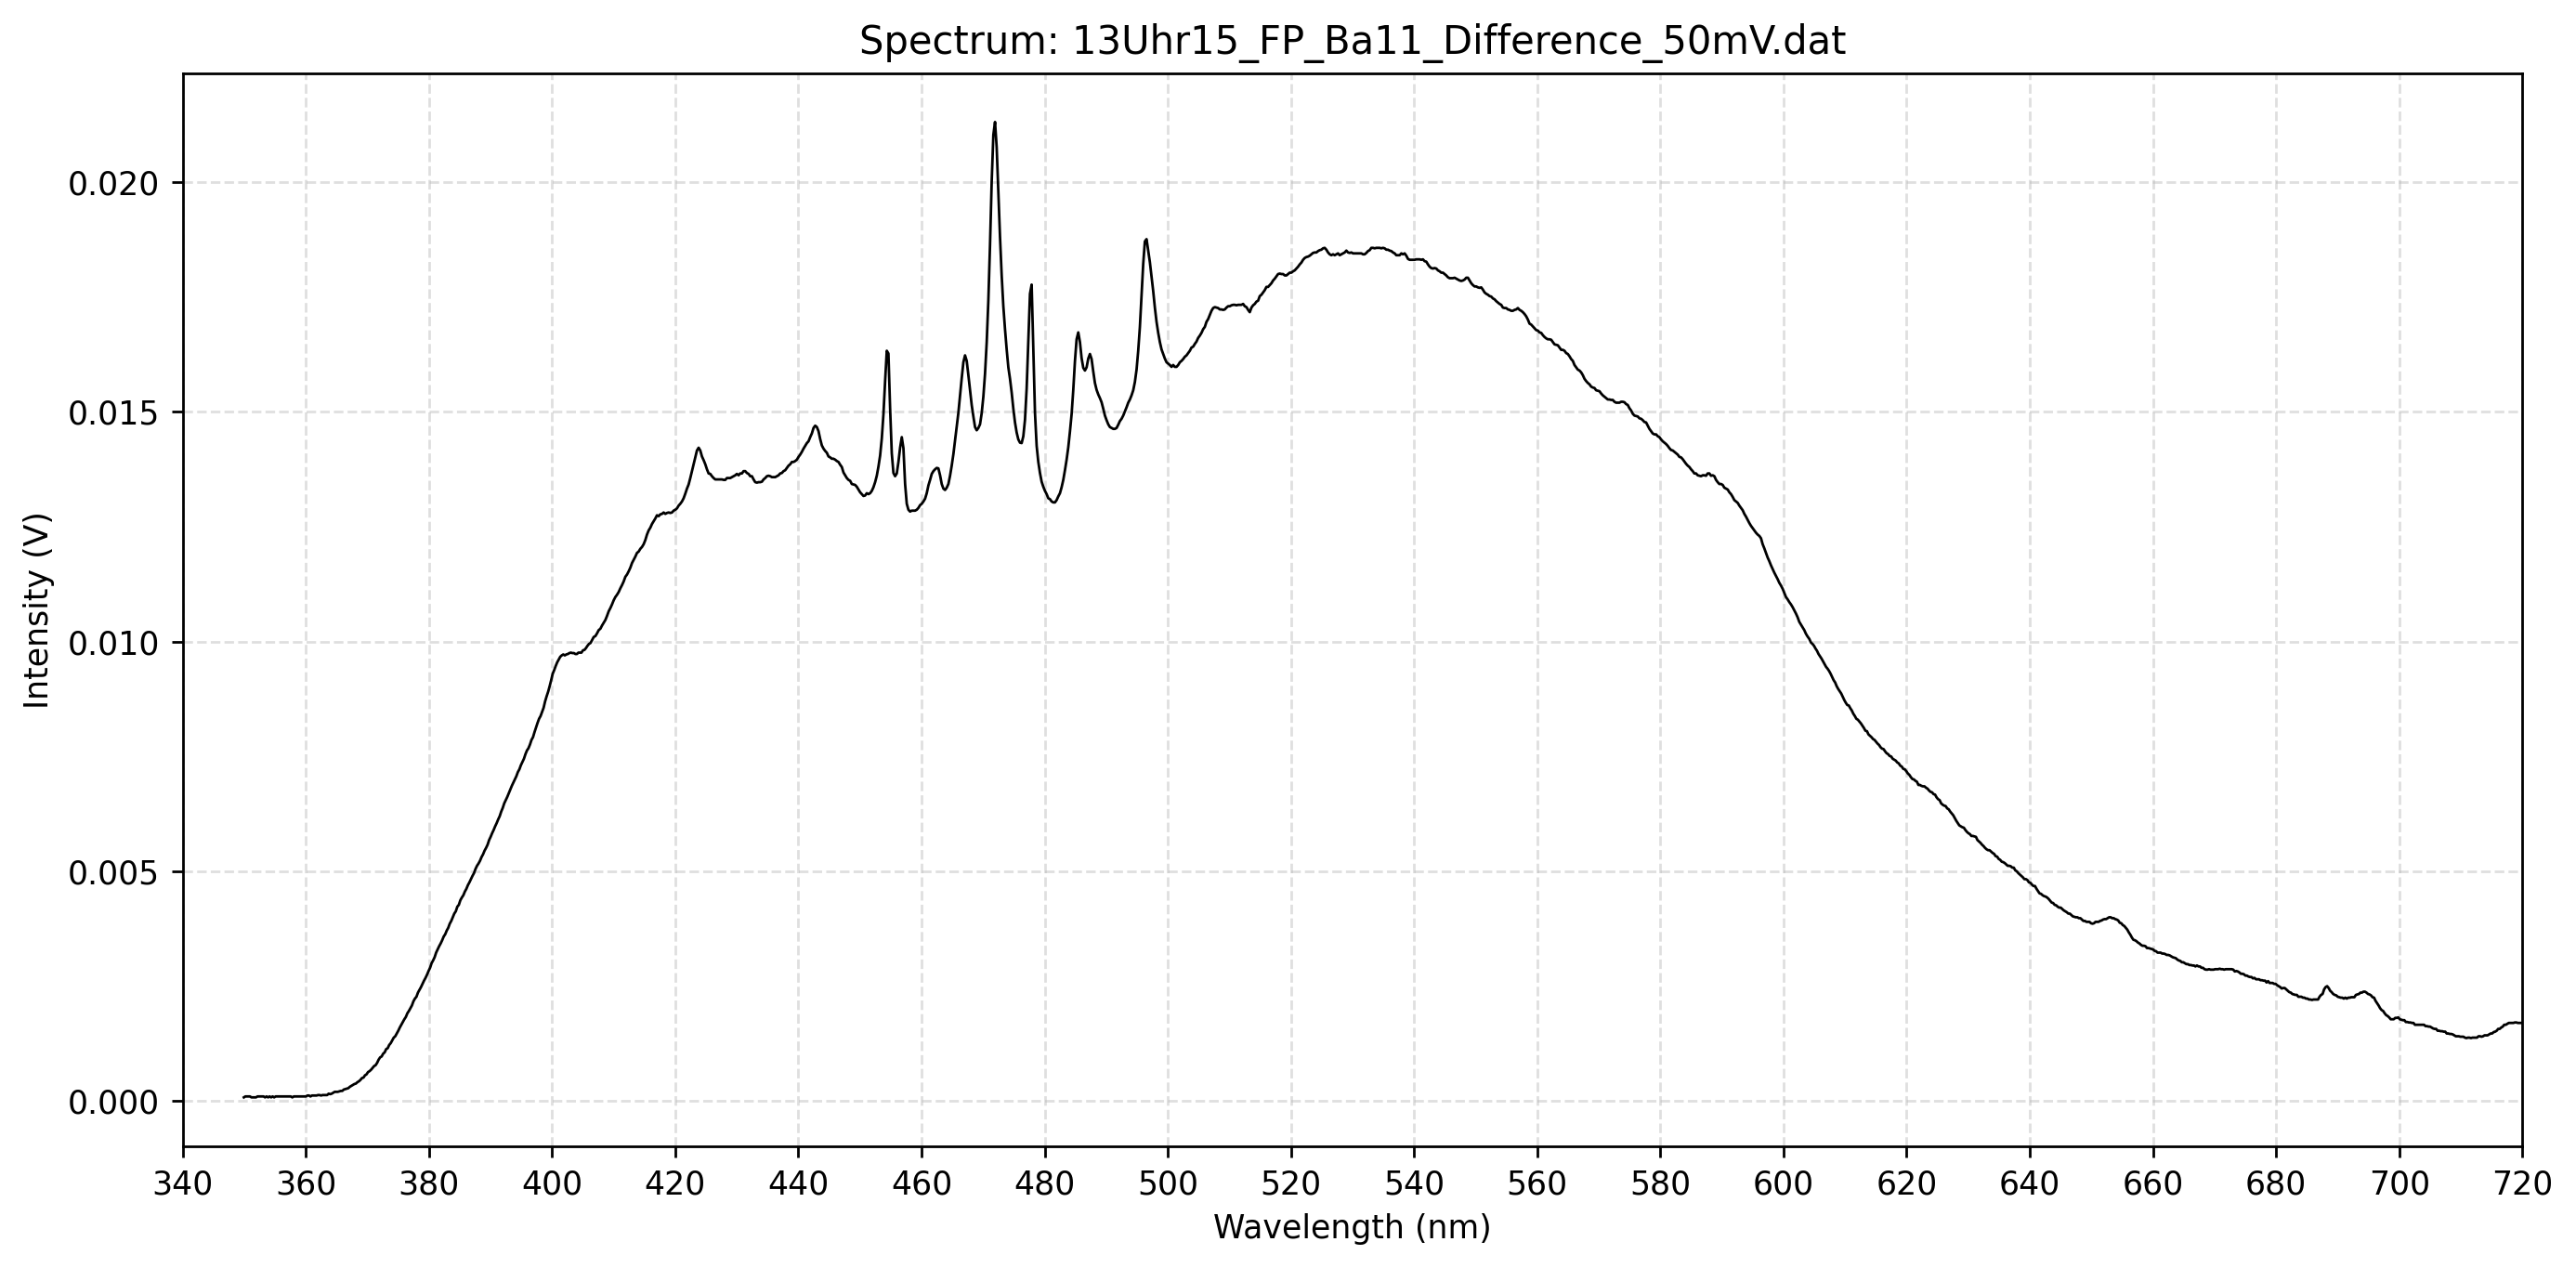

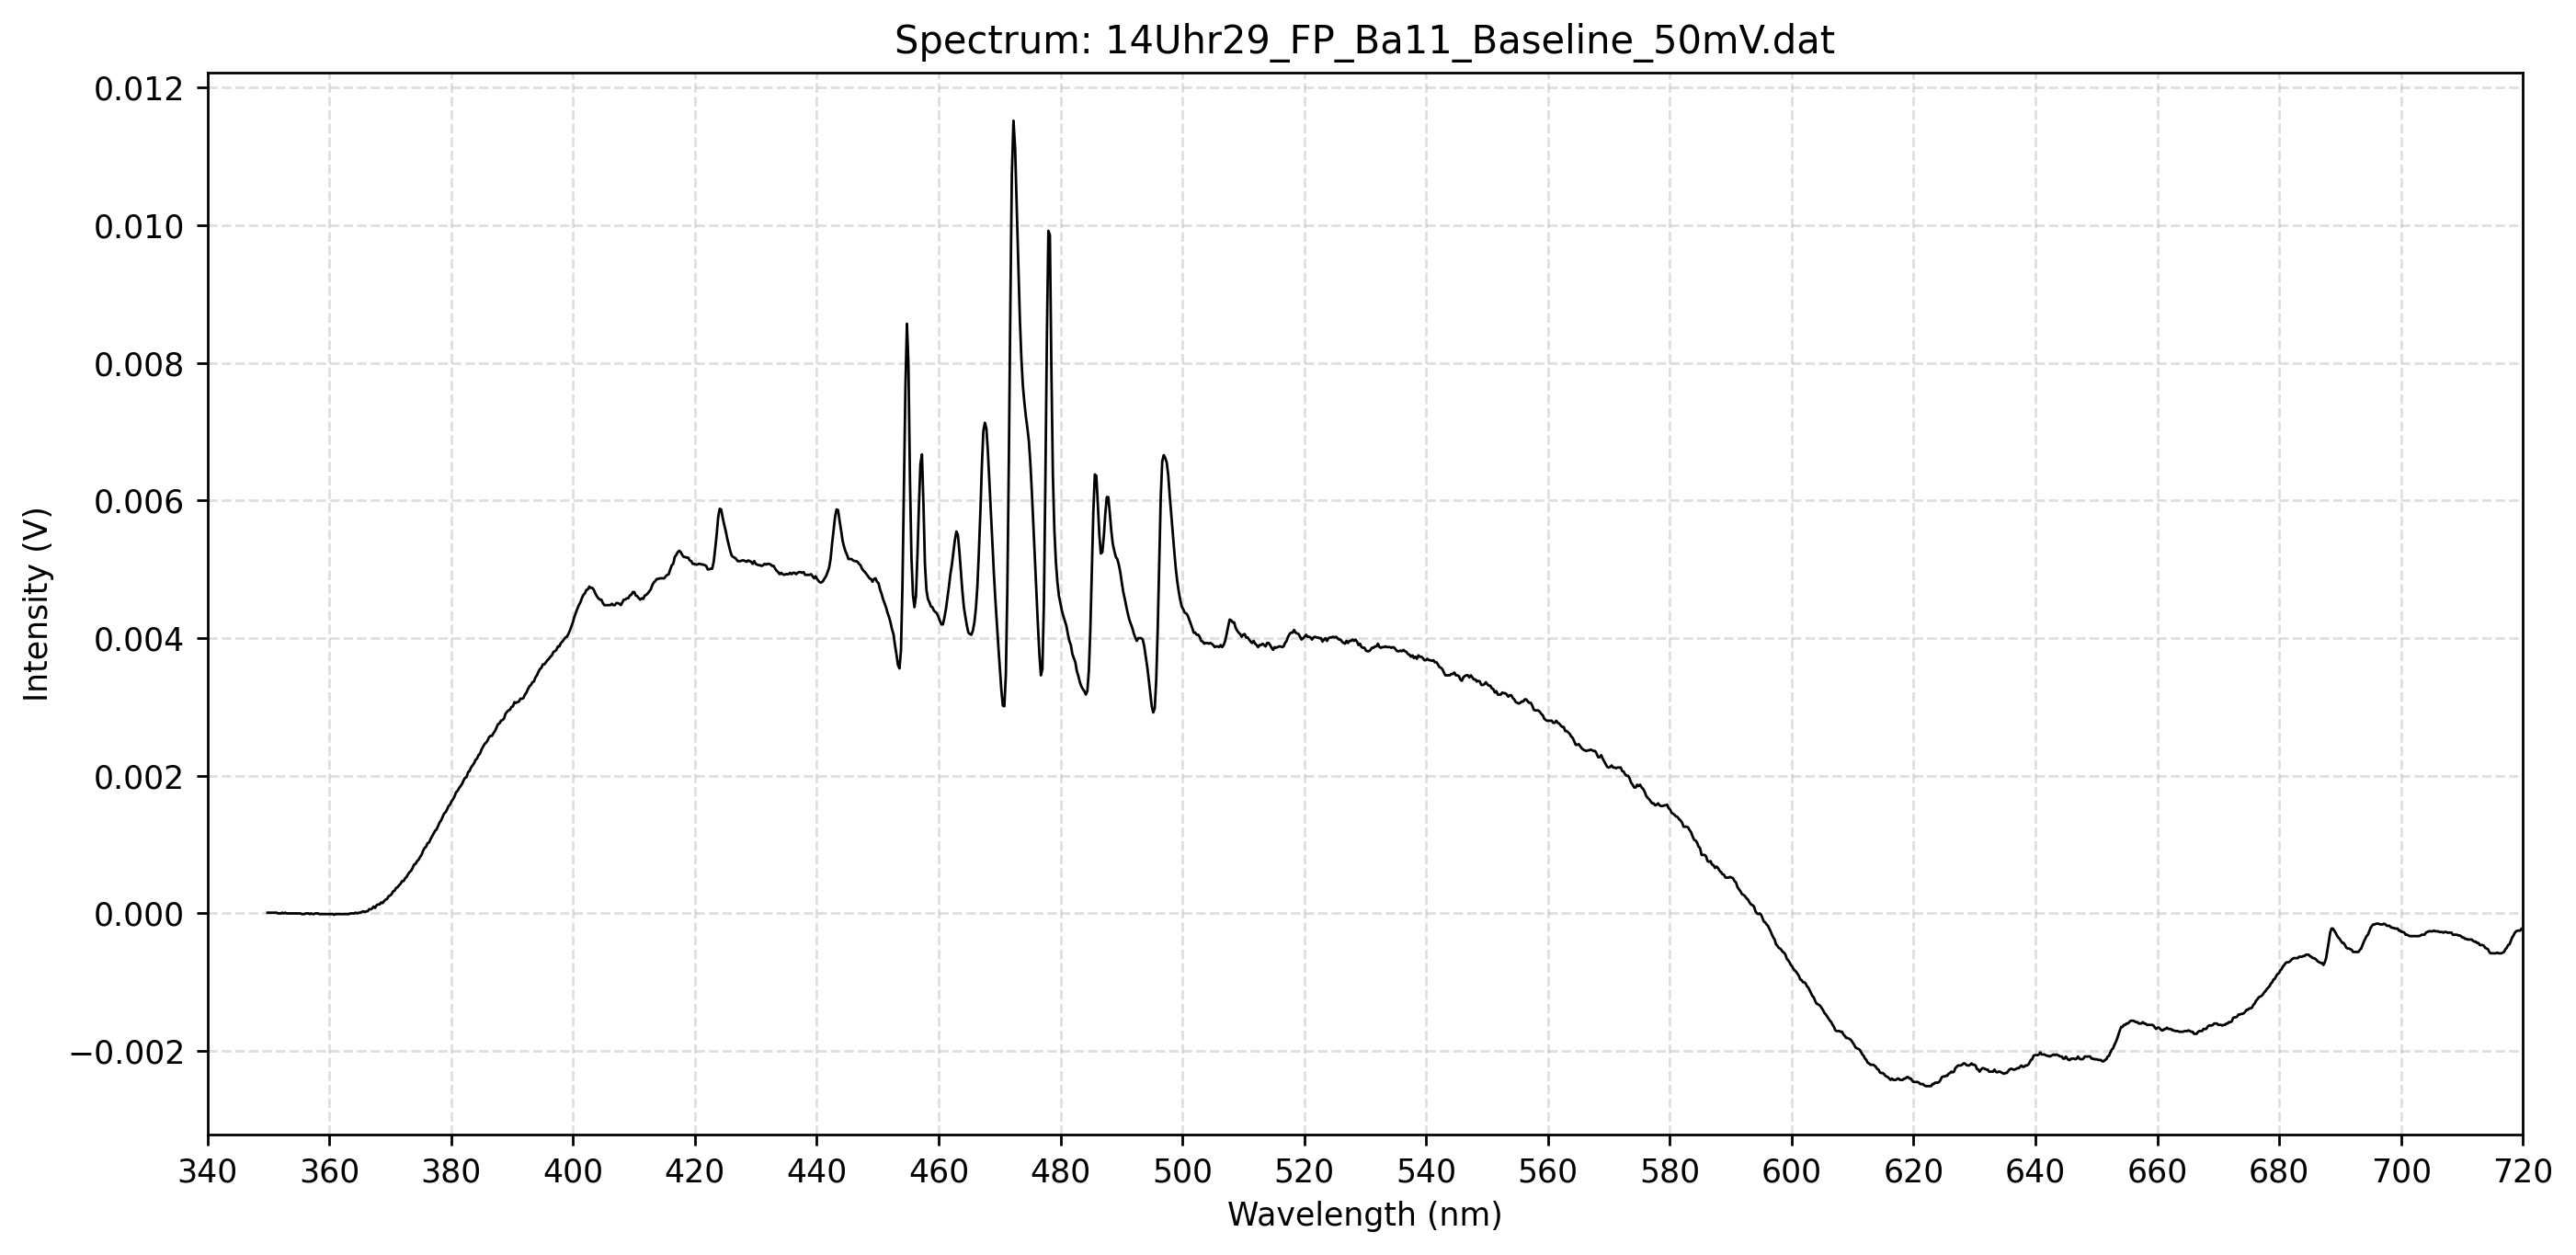

1568
1433
[349.878 350.122 350.369 ... 719.543 719.778 720.   ]
[349.951 350.197 350.443 ... 719.507 719.753 720.   ]


In [12]:
#hg_wavelength, hg_intensity = extract_data("")
#print(hg_wavelength)
#plot_spectrum("15Uhr03_FP_Ba11_Hg_Spectrum_50mV.dat")
diff_wavelength, diff_intensity = extract_data("13Uhr15_FP_Ba11_Difference_50mV.dat")
#plot_spectrum("13Uhr26_FP_Ba11_Xenon_50mV.dat")
#plot_spectrum("13Uhr36_FP_Ba11_Ruby_50mV.dat")
#plot_spectrum("13Uhr51_FP_Ba11_Difference_5mV.dat")
#plot_spectrum("13Uhr57_FP_Ba11_Xenon_5mV.dat")
#plot_spectrum("14Uhr10_FP_Ba11_Ruby_5mV.dat")
baseline_wavelength, baseline_intensity = extract_data("14Uhr29_FP_Ba11_Baseline_50mV.dat")
#plot_spectrum("14Uhr44_FP_Ba11_Baseline_5mV.dat")

print(len(baseline_wavelength))
print(len(diff_wavelength))
print(baseline_wavelength)
print(diff_wavelength)

In [2]:
# Function to extract wavelength and intensity from the data
import numpy as np
import matplotlib.pyplot as plt

def load_spectrum(filename):
    """
    Return wavelength[n], intensity[n] from a Ba11 (ISO) spectrum file.
    """

    # --- Load file and convert commas to dots ---
    with open(filename, "r", encoding="utf-8") as f:
        header1 = f.readline().strip().replace(",", ".")  # start wavelength [nm]
        header2 = f.readline().strip().replace(",", ".")  # gear factor [nm/s]
        header3 = f.readline().strip().replace(",", ".")  # scan direction

        data = np.loadtxt(
            (line.replace(",", ".") for line in f),
            ndmin=2
        )

    # --- Parse metadata ---
    start_wavelength = float(header1)
    gear = float(header2)        # nm per second
    direction = float(header3)   # +1 or -1

    # --- Extract data ---
    t = data[:, 0]               # time [s]
    intensity_raw = data[:, 1]   # voltage [V]
    intensity = -intensity_raw   # flip sign → absorption peaks upward

    # --- Wavelength axis ---
    wavelength = start_wavelength + direction * gear * t

    # Ensure increasing wavelength
    if wavelength[0] > wavelength[-1]:
        wavelength = wavelength[::-1]
        intensity = intensity[::-1]

    return wavelength, intensity


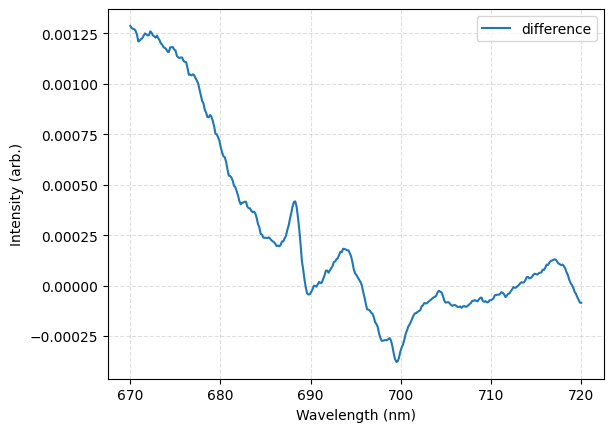

In [3]:
# Load
wl1, I1 = load_spectrum("13Uhr51_FP_Ba11_Difference_5mV.dat")
wl2, I2 = load_spectrum("14Uhr44_FP_Ba11_Baseline_5mV.dat")

# Common wavelength axis (overlap region)
wl_min = max(wl1.min(), wl2.min())
wl_max = min(wl1.max(), wl2.max())
dw = np.mean(np.diff(wl1))  # or choose manually
wl_common = np.arange(wl_min, wl_max, dw)

# Interpolate both
I1i = np.interp(wl_common, wl1, I1)
I2i = np.interp(wl_common, wl2, I2)

# Difference
Idiff = I1i - I2i

# Plot
plt.figure()
plt.plot(wl_common, Idiff, label="difference")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (arb.)")
plt.grid(True, alpha=0.4, linestyle="--")
plt.legend()
plt.show()
